# Analyse des opérations NOP — tous les tags

**Contexte** — chaque tag listé ci-dessous est un compteur cumulatif
d'opérations (`value_nop`), échantillonné à la minute, pour une ligne de
production différente. Le compteur reste constant pendant qu'une opération
est en cours, puis change de valeur au passage à l'opération suivante : une
opération correspond donc à un plateau de valeur constante — même modèle que
`OI_NOP_analysis.ipynb`, mais reconduit ici **pour tous les tags à la fois**.

**Objectif** — pour chaque tag :
1. reconstruire les opérations et écarter les durées incohérentes (bruit
   capteur, arrêts prolongés) ;
2. estimer, à partir des données elles-mêmes, la taille de fenêtre (nombre
   d'opérations consécutives) dont la meilleure séquence couvre ~7 jours —
   plutôt que de supposer a priori que 35 opérations = 7 jours ;
3. calculer sur cette fenêtre le **Golden Score** (capacité en ops/jour +
   temps standard d'une opération), qui sert de **Best Demonstrated
   Performance (BDP)** et donc de **TCD (Theoretical Production Rate)** pour
   le calcul d'OEE ;
4. produire un tableau de synthèse comparatif entre tags, puis le détail
   visuel (répartition des durées, meilleure série observée) pour chacun.

**Méthodologie** — toute la logique métier réutilisable reste dans le
package `nop_analysis/` (nettoyage, extraction, KPI, scoring, graphiques),
inchangé. Ce notebook ne fait qu'orchestrer ces fonctions **en boucle sur
tous les tags** et assembler les résultats.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from tools.OI_class_OP import OI_DataProcessor
import nop_analysis as nopa
from nop_analysis import plots, config

pd.set_option('display.max_columns', None)


## 1. Chargement des données

Les données sont extraites via le processeur de production `OI_DataProcessor`,
qui interroge l'API OIAnalytics.

**Point important** — dans la version précédente de ce notebook, tous les
tags partageaient le même `nom` (`value_nop`), ce qui provoquait des colonnes
en double après renommage (`processor.data` ne contenait alors plus qu'une
seule colonne exploitable, celle du dernier tag chargé) : le notebook ne
fonctionnait donc qu'avec un seul tag à la fois. Ici, chaque tag garde son
propre nom de colonne (`nom` = `tag`), ce qui permet de tous les charger et
analyser en une seule fois, tout en gardant un seul appel à `merge()`.


In [2]:
tags = [
    {'tag': 'NOP_ACETATE', 'nom': 'NOP_ACETATE', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_ESTERS', 'nom': 'NOP_ESTERS', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_RETINOL', 'nom': 'NOP_RETINOL', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_RHQ', 'nom': 'NOP_RHQ', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_RETINENE', 'nom': 'NOP_RETINENE', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_SC15', 'nom': 'NOP_SC15', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'OP1510VA_CPT', 'nom': 'OP1510VA_CPT', 'info': "Nombre des opérations", 'agg': 'FIRST'},
    {'tag': 'NOP_AOIP', 'nom': 'NOP_AOIP', 'info': "Nombre des opérations", 'agg': 'FIRST'},
]

processor = OI_DataProcessor(
    url_base='https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start='2023-01-01',
    end='2026-12-31',
    tags_selected=tags,
    tags_other=[],
    interval='PT01M',
    verbose=False,
    agg='FIRST'
)

processor.merge()
processor.data.describe()


,NOP_ACETATE,NOP_ESTERS,NOP_RETINOL,NOP_RHQ,NOP_RETINENE,NOP_SC15,OP1510VA_CPT,NOP_AOIP
count,1.848725e+06,1.848725e+06,1.848725e+06,1.848725e+06,1.848725e+06,1.848725e+06,1.848331e+06,1.848725e+06
mean,1.146122e+03,1.195197e+03,1.067748e+03,1.143872e+03,1.086150e+03,8.769287e+02,1.011627e+03,8.944795e+02
std,6.168434e+02,6.458472e+02,5.901105e+02,6.154601e+02,5.823253e+02,4.696650e+02,5.409077e+02,4.764412e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.080000e+02,6.300000e+02,6.070000e+02,6.070000e+02,5.840000e+02,4.700000e+02,5.420000e+02,4.780000e+02
50%,1.247000e+03,1.317000e+03,1.094000e+03,1.244000e+03,1.175000e+03,9.560000e+02,1.096000e+03,9.680000e+02
75%,1.633000e+03,1.714000e+03,1.528000e+03,1.631000e+03,1.541000e+03,1.245000e+03,1.440000e+03,1.270000e+03
max,2.228000e+03,2.294000e+03,2.231000e+03,2.225000e+03,2.121000e+03,1.702000e+03,1.974000e+03,1.740000e+03


## 2. Nettoyage — qualité des données brutes, par tag

Même nettoyage que `nop_analysis.clean_dataframe` (suppression des `NaN`,
des valeurs négatives, conversion en entier), appliqué séparément à chaque
tag pour vérifier qu'aucun ne présente une proportion anormale de valeurs
écartées avant de poursuivre.


In [3]:
quality_rows = []

for tag_def in tags:
    label, nom = tag_def['tag'], tag_def['nom']
    if nom not in processor.data.columns:
        quality_rows.append({'Tag': label, 'N brut (non-NaN)': 0, 'N après nettoyage': 0, '% écarté': np.nan})
        continue

    raw = processor.data[[nom]]
    n_raw = int(raw[nom].notna().sum())
    clean = nopa.clean_dataframe(raw, value_col=nom)
    quality_rows.append({
        'Tag': label,
        'N brut (non-NaN)': n_raw,
        'N après nettoyage': len(clean),
        '% écarté': round((1 - len(clean) / n_raw) * 100, 2) if n_raw else np.nan,
    })

quality_table = pd.DataFrame(quality_rows)
quality_table


,Tag,N brut (non-NaN),N après nettoyage,% écarté
0,NOP_ACETATE,1848725,1848725,0.0
1,NOP_ESTERS,1848725,1848725,0.0
2,NOP_RETINOL,1848725,1848725,0.0
3,NOP_RHQ,1848725,1848725,0.0
4,NOP_RETINENE,1848725,1848725,0.0
5,NOP_SC15,1848725,1848725,0.0
6,OP1510VA_CPT,1848331,1848331,0.0
7,NOP_AOIP,1848725,1848725,0.0


## 3. Extraction des opérations et estimation de la fenêtre BDP

Pour chaque tag :

- **Reconstruction des opérations** (`nopa.extract_operations`) — un plateau
  de valeur constante = une opération.
- **Filtrage des durées incohérentes** (`nopa.filter_operations_by_duration`)
  — on écarte tout ce qui sort de
  `[config.MIN_OPERATION_DURATION, config.MAX_OPERATION_DURATION]` : un
  signal trop court est du bruit capteur, un signal trop long est un arrêt
  de ligne prolongé — ni l'un ni l'autre n'est représentatif d'une opération
  standard.
- **Estimation de la fenêtre BDP** (`find_bdp_window`, ci-dessous) — au lieu
  de supposer que 35 opérations représentent toujours ~7 jours (hypothèse
  valable pour un seul tag/procédé, mais pas généralisable à tous), on
  cherche pour *chaque* tag la taille de fenêtre dont la meilleure séquence
  consécutive couvre une durée proche de 7 jours. On part de
  `config.GOLDEN_RUN_WINDOW` (35) et on ajuste par itération
  (`nouvelle fenêtre = fenêtre × 7 / jours observés`) jusqu'à convergence :
  peu d'itérations suffisent car la durée totale d'une séquence croît
  quasi-linéairement avec le nombre d'opérations qu'elle contient.

Cette fenêtre estimée devient la référence **Golden Score / BDP / TCD** du
tag (section 4).


In [4]:
def find_bdp_window(ops, target_days=7, initial_window=None, w_min=3, max_iter=8):
    """
    Estime la taille de fenêtre (nb d'opérations consécutives) dont la
    meilleure séquence couvre une durée proche de `target_days` jours.

    Remplace l'hypothèse fixe (35 opérations ~= 7 jours) par une estimation
    propre à chaque tag, par ajustement itératif du ratio
    jours_cible / jours_observés.

    Returns
    -------
    (best_window, cache) où cache = {window: result} pour toutes les
    fenêtres testées (résultats de nopa.analyze_best_runs), afin d'éviter
    de recalculer ce qui l'a déjà été.
    """
    n = len(ops)
    w_max = n - 1
    if w_max < w_min:
        return None, {}

    w = int(np.clip(initial_window or config.GOLDEN_RUN_WINDOW, w_min, w_max))
    seen = {}

    for _ in range(max_iter):
        if w in seen:
            break
        result = nopa.analyze_best_runs(ops, window_sizes=(w,)).get(w)
        if result is None:
            break
        seen[w] = result

        days = (result['end_time'] - result['start_time']).total_seconds() / 86400
        if days <= 0:
            break

        next_w = int(np.clip(round(w * target_days / days), w_min, w_max))
        if next_w == w:
            break
        w = next_w

    if not seen:
        return None, {}

    def _gap(window):
        r = seen[window]
        days = (r['end_time'] - r['start_time']).total_seconds() / 86400
        return abs(days - target_days)

    best_window = min(seen, key=_gap)
    return best_window, seen


def trend_label(monthly, col, min_points=2):
    """Pente d'une régression linéaire simple sur une série mensuelle -> libellé qualitatif."""
    values = monthly[col].to_numpy() if len(monthly) else np.array([])
    if len(values) < min_points:
        return "non déterminable"
    slope = np.polyfit(np.arange(len(values)), values, 1)[0]
    if abs(slope) < 1e-9:
        return "stabilité"
    return "amélioration" if slope > 0 else "dégradation"


In [5]:
TARGET_DAYS = 7
MIN_OPS_FOR_ANALYSIS = config.MONTHLY_ROLLING_WINDOW + 1

tag_reports = {}
skipped_tags = []

for tag_def in tags:
    label, nom = tag_def['tag'], tag_def['nom']

    if nom not in processor.data.columns:
        skipped_tags.append((label, "colonne absente des données chargées"))
        continue

    raw = processor.data[[nom]]
    ops = nopa.extract_operations(raw, value_col=nom)
    n_raw = len(ops)
    ops = nopa.filter_operations_by_duration(
        ops,
        min_duration=config.MIN_OPERATION_DURATION,
        max_duration=config.MAX_OPERATION_DURATION,
        verbose=False,
    )

    if len(ops) < MIN_OPS_FOR_ANALYSIS:
        skipped_tags.append((label, f"trop peu d'opérations exploitables ({len(ops)}/{n_raw})"))
        continue

    bdp_window, window_scan = find_bdp_window(ops, target_days=TARGET_DAYS)
    if bdp_window is None:
        skipped_tags.append((label, "estimation de la fenêtre BDP impossible"))
        continue

    golden = {'window': bdp_window, 'result': window_scan[bdp_window]}
    evaluation = nopa.evaluate_golden_run(ops, golden)

    comparison_windows = tuple(sorted(set(config.DEFAULT_WINDOW_SIZES) | {bdp_window, config.GOLDEN_RUN_WINDOW}))
    comparison_results = nopa.analyze_best_runs(ops, window_sizes=comparison_windows)

    limits = nopa.compute_control_limits(ops)
    flagged = nopa.flag_out_of_control(ops, limits)

    zscored = nopa.compute_zscore(ops, window=bdp_window)
    monthly_zscore = nopa.compute_monthly_zscore(zscored)
    monthly_cv = nopa.compute_monthly_cv(ops)
    monthly_scores = nopa.compute_monthly_scores(ops, window=config.MONTHLY_ROLLING_WINDOW)

    r = golden['result']
    d = ops['duration_min']
    ref35 = comparison_results.get(config.GOLDEN_RUN_WINDOW)

    tag_reports[label] = {
        'tag': label,
        'nom': nom,
        'info': tag_def.get('info', ''),
        'n_ops_bruts': n_raw,
        'n_ops': len(ops),
        'periode_debut': ops['start'].min(),
        'periode_fin': ops['end'].max(),
        'mean_duration_min': d.mean(),
        'median_duration_min': d.median(),
        'std_duration_min': d.std(),
        'cv_global': d.std() / d.mean(),
        'bdp_window': bdp_window,
        'bdp_days_covered': (r['end_time'] - r['start_time']).total_seconds() / 86400,
        'bdp_run_start': r['start_time'],
        'bdp_run_end': r['end_time'],
        'bdp_mean_duration_min': r['mean_duration_min'],
        'bdp_median_duration_min': r['median_duration_min'],
        'bdp_cv': r['cv'],
        'golden_score_ops_per_day': r['capacity_per_day'],
        'tcd_ops_per_day': r['capacity_per_day'],
        'tcd_ops_per_hour': r['capacity_per_day'] / 24,
        'reference_window35_ops_per_day': ref35['capacity_per_day'] if ref35 else np.nan,
        'reference_window35_days_covered': (
            (ref35['end_time'] - ref35['start_time']).total_seconds() / 86400 if ref35 else np.nan
        ),
        'n_atypical_ops_in_bdp_run': evaluation['n_atypical_ops_in_run'],
        'n_out_of_control': int(flagged['out_of_control'].sum()),
        'cv_verdict': evaluation['cv_verdict'],
        'trend_zscore': trend_label(monthly_zscore, 'mean_z'),
        'ops': ops,
        'golden': golden,
        'evaluation': evaluation,
        'comparison_results': comparison_results,
        'monthly_scores': monthly_scores,
        'monthly_zscore': monthly_zscore,
        'monthly_cv': monthly_cv,
        'limits': limits,
    }

    print(
        f"[{label}] {len(ops):,} opérations retenues ({n_raw:,} avant filtrage durée) — "
        f"fenêtre BDP estimée : {bdp_window} ops ({tag_reports[label]['bdp_days_covered']:.1f} j) — "
        f"Golden Score / TCD : {r['capacity_per_day']:.2f} ops/j — "
        f"temps standard : {r['mean_duration_min']:.1f} min/op"
    )

if skipped_tags:
    print("\nTags écartés de l'analyse :")
    for label, reason in skipped_tags:
        print(f"  - {label} : {reason}")


[NOP_ACETATE] 2,995 opérations retenues (3,075 avant filtrage durée) — fenêtre BDP estimée : 26 ops (6.9 j) — Golden Score / TCD : 3.74 ops/j — temps standard : 384.8 min/op
[NOP_ESTERS] 3,069 opérations retenues (3,149 avant filtrage durée) — fenêtre BDP estimée : 29 ops (7.0 j) — Golden Score / TCD : 4.14 ops/j — temps standard : 347.9 min/op
[NOP_RETINOL] 2,996 opérations retenues (3,076 avant filtrage durée) — fenêtre BDP estimée : 26 ops (7.0 j) — Golden Score / TCD : 3.70 ops/j — temps standard : 389.6 min/op
[NOP_RHQ] 2,995 opérations retenues (3,067 avant filtrage durée) — fenêtre BDP estimée : 26 ops (7.1 j) — Golden Score / TCD : 3.68 ops/j — temps standard : 391.7 min/op
[NOP_RETINENE] 2,843 opérations retenues (2,914 avant filtrage durée) — fenêtre BDP estimée : 23 ops (6.9 j) — Golden Score / TCD : 3.32 ops/j — temps standard : 434.0 min/op
[NOP_SC15] 2,242 opérations retenues (2,338 avant filtrage durée) — fenêtre BDP estimée : 19 ops (7.1 j) — Golden Score / TCD : 2.67 o

### 3bis. Filtrage des durées incohérentes — vue explicite par tag

Le tableau de qualité de la section 2 ne portait que sur le signal brut
(`NaN`/valeurs négatives) : il est normal qu'il affiche 0% pour un capteur
sain. Le filtrage qui compte réellement (durées d'opération hors
`[config.MIN_OPERATION_DURATION, config.MAX_OPERATION_DURATION]`, cf. section
suivante) est appliqué plus haut dans la boucle — ce tableau le rend visible
explicitement, tag par tag, plutôt que de le laisser uniquement dans les
messages imprimés.


In [6]:
skip_reasons = dict(skipped_tags)

duration_filter_rows = []
for tag_def in tags:
    label = tag_def['tag']
    rep = tag_reports.get(label)
    if rep is not None:
        n_raw, n_ops = rep['n_ops_bruts'], rep['n_ops']
        duration_filter_rows.append({
            'Tag': label,
            'N ops brutes (avant filtrage durée)': n_raw,
            'N ops retenues (après filtrage durée)': n_ops,
            'N ops écartées': n_raw - n_ops,
            '% écarté': round((1 - n_ops / n_raw) * 100, 2) if n_raw else np.nan,
            'Statut': 'OK',
        })
    else:
        duration_filter_rows.append({
            'Tag': label,
            'N ops brutes (avant filtrage durée)': np.nan,
            'N ops retenues (après filtrage durée)': np.nan,
            'N ops écartées': np.nan,
            '% écarté': np.nan,
            'Statut': skip_reasons.get(label, 'non traité'),
        })

duration_filter_table = pd.DataFrame(duration_filter_rows)
duration_filter_table


,Tag,N ops brutes (avant filtrage durée),N ops retenues (après filtrage durée),N ops écartées,% écarté,Statut
0,NOP_ACETATE,3075,2995,80,2.60,OK
1,NOP_ESTERS,3149,3069,80,2.54,OK
2,NOP_RETINOL,3076,2996,80,2.60,OK
3,NOP_RHQ,3067,2995,72,2.35,OK
4,NOP_RETINENE,2914,2843,71,2.44,OK
5,NOP_SC15,2338,2242,96,4.11,OK
6,OP1510VA_CPT,2693,2586,107,3.97,OK
7,NOP_AOIP,2368,2252,116,4.90,OK


## 4. Tableau de synthèse comparatif

Une ligne par tag, avec :

- les statistiques globales de durée (moyenne, médiane, écart-type, CV) ;
- la **fenêtre BDP** estimée (nombre d'opérations dont la meilleure séquence
  couvre ~7 jours) et le nombre de jours réellement couverts ;
- le **temps standard** d'une opération sur ce run (min/op) ;
- le **Golden Score / BDP** et le **TCD** qui en dérive (ops/jour, ops/heure)
  — à utiliser comme référence de capacité théorique pour le calcul d'OEE
  (`Performance = débit réel / TCD`) ;
- la capacité équivalente qu'aurait donné l'hypothèse fixe à 35 opérations,
  à titre de comparaison ;
- des indicateurs de fiabilité de la référence (CV du run, opérations
  atypiques, points hors contrôle SPC) et la tendance mensuelle (z-score).


In [7]:
summary_rows = []
for label, rep in tag_reports.items():
    summary_rows.append({
        'Tag': label,
        'Info': rep['info'],
        'Période': f"{rep['periode_debut']:%Y-%m-%d} -> {rep['periode_fin']:%Y-%m-%d}",
        'N ops (nettoyées)': rep['n_ops'],
        'Durée moy. (min)': round(rep['mean_duration_min'], 1),
        'Durée méd. (min)': round(rep['median_duration_min'], 1),
        'CV global': round(rep['cv_global'], 2),
        'Fenêtre BDP (n ops)': rep['bdp_window'],
        'Jours couverts (BDP)': round(rep['bdp_days_covered'], 1),
        'Temps standard (min/op)': round(rep['bdp_mean_duration_min'], 1),
        'Golden Score / BDP (ops/j)': round(rep['golden_score_ops_per_day'], 2),
        'TCD (ops/j)': round(rep['tcd_ops_per_day'], 2),
        'TCD (ops/h)': round(rep['tcd_ops_per_hour'], 3),
        'Réf. fenêtre 35 (ops/j)': (
            round(rep['reference_window35_ops_per_day'], 2)
            if pd.notna(rep['reference_window35_ops_per_day']) else np.nan
        ),
        'CV run BDP': round(rep['bdp_cv'], 2),
        'Ops atypiques (run BDP)': rep['n_atypical_ops_in_bdp_run'],
        'Hors contrôle SPC': rep['n_out_of_control'],
        'Tendance (z-score mensuel)': rep['trend_zscore'],
    })

summary_table = (
    pd.DataFrame(summary_rows)
    .sort_values('Golden Score / BDP (ops/j)', ascending=False)
    .reset_index(drop=True)
)
summary_table


,Tag,Info,Période,N ops (nettoyées),Durée moy. (min),Durée méd. (min),CV global,Fenêtre BDP (n ops),Jours couverts (BDP),Temps standard (min/op),Golden Score / BDP (ops/j),TCD (ops/j),TCD (ops/h),Réf. fenêtre 35 (ops/j),CV run BDP,Ops atypiques (run BDP),Hors contrôle SPC,Tendance (z-score mensuel)
0,NOP_ESTERS,Nombre des opérations,2023-01-05 -> 2026-07-12,3069,482.0,426.0,0.36,29,7.0,347.9,4.14,4.14,0.172,4.11,0.18,0,163,amélioration
1,NOP_ACETATE,Nombre des opérations,2023-01-05 -> 2026-07-12,2995,495.4,435.0,0.34,26,6.9,384.8,3.74,3.74,0.156,3.65,0.08,0,175,dégradation
2,NOP_RETINOL,Nombre des opérations,2023-01-04 -> 2026-07-12,2996,494.9,436.0,0.33,26,7.0,389.6,3.70,3.70,0.154,3.65,0.01,0,189,dégradation
3,NOP_RHQ,Nombre des opérations,2023-01-04 -> 2026-07-12,2995,496.7,435.0,0.33,26,7.1,391.7,3.68,3.68,0.153,3.67,0.02,0,220,dégradation
4,NOP_RETINENE,Nombre des opérations,2023-01-02 -> 2026-07-12,2843,522.2,451.0,0.28,23,6.9,434.0,3.32,3.32,0.138,3.29,0.01,0,189,amélioration
5,OP1510VA_CPT,Nombre des opérations,2023-01-02 -> 2026-07-12,2586,527.5,481.0,0.26,23,7.0,436.4,3.30,3.30,0.137,3.28,0.01,0,154,amélioration
6,NOP_AOIP,Nombre des opérations,2023-01-02 -> 2026-07-12,2252,577.5,542.5,0.26,16,5.0,453.9,3.17,3.17,0.132,3.09,0.04,0,145,amélioration
7,NOP_SC15,Nombre des opérations,2023-01-01 -> 2026-07-10,2242,642.2,578.0,0.24,19,7.1,539.9,2.67,2.67,0.111,2.63,0.01,0,185,amélioration


### 4bis. Tableau synthétique condensé

Version courte du tableau ci-dessus : juste de quoi comparer les tags d'un
coup d'œil (temps moyen/médian d'une opération, taille du run golden retenu,
TCD qui en découle).


In [8]:
compact_table = summary_table[[
    'Tag',
    'N ops (nettoyées)',
    'Durée moy. (min)',
    'Durée méd. (min)',
    'Fenêtre BDP (n ops)',
    'TCD (ops/j)',
    'Temps standard (min/op)',
]].rename(columns={'Fenêtre BDP (n ops)': 'Nb ops run golden'})

compact_table


,Tag,N ops (nettoyées),Durée moy. (min),Durée méd. (min),Nb ops run golden,TCD (ops/j),Temps standard (min/op)
0,NOP_ESTERS,3069,482.0,426.0,29,4.14,347.9
1,NOP_ACETATE,2995,495.4,435.0,26,3.74,384.8
2,NOP_RETINOL,2996,494.9,436.0,26,3.70,389.6
3,NOP_RHQ,2995,496.7,435.0,26,3.68,391.7
4,NOP_RETINENE,2843,522.2,451.0,23,3.32,434.0
5,OP1510VA_CPT,2586,527.5,481.0,23,3.30,436.4
6,NOP_AOIP,2252,577.5,542.5,16,3.17,453.9
7,NOP_SC15,2242,642.2,578.0,19,2.67,539.9


## 5. Comparaison visuelle entre tags

Golden Score / TCD (capacité, ops/jour) et temps standard (min/opération),
classés du plus performant au moins performant.


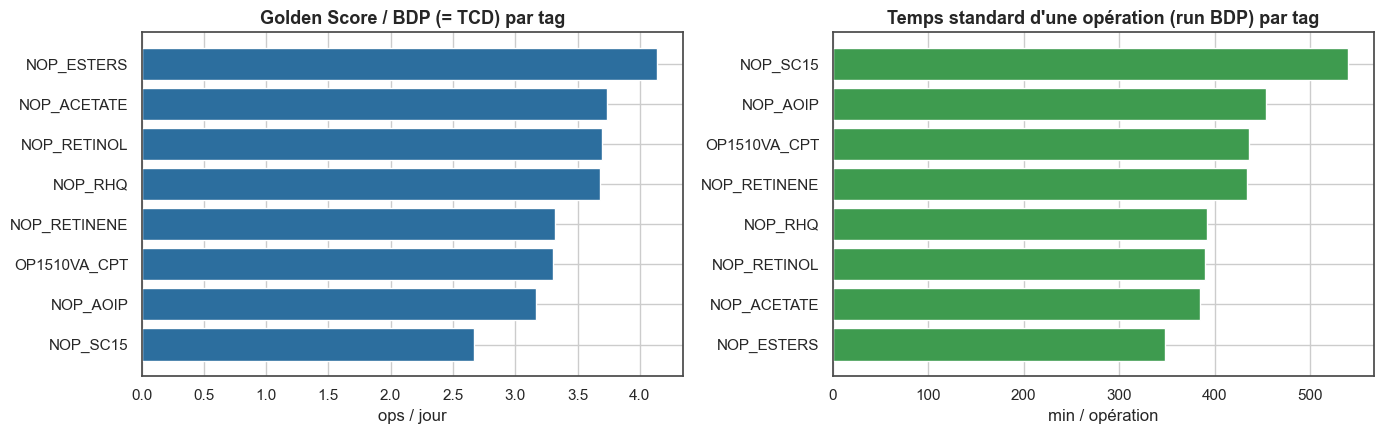

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 0.5 + 0.5 * len(summary_table)))

by_capacity = summary_table.sort_values('Golden Score / BDP (ops/j)')
axes[0].barh(by_capacity['Tag'], by_capacity['Golden Score / BDP (ops/j)'], color='#2C6E9E')
axes[0].set_xlabel('ops / jour')
axes[0].set_title('Golden Score / BDP (= TCD) par tag')

by_duration = summary_table.sort_values('Temps standard (min/op)')
axes[1].barh(by_duration['Tag'], by_duration['Temps standard (min/op)'], color='#3E9B4F')
axes[1].set_xlabel('min / opération')
axes[1].set_title("Temps standard d'une opération (run BDP) par tag")

plt.tight_layout()
plt.show()


## 6. Détail par tag

Pour chaque tag : distribution des durées, tableau de bord du run BDP
(timeline complète avec la meilleure séquence mise en évidence, stabilité du
run, capacité vs taille de fenêtre) et synthèse texte générée automatiquement
(`nopa.build_summary_report`, inchangée — appelée ici une fois par tag).


### NOP_ACETATE — Nombre des opérations

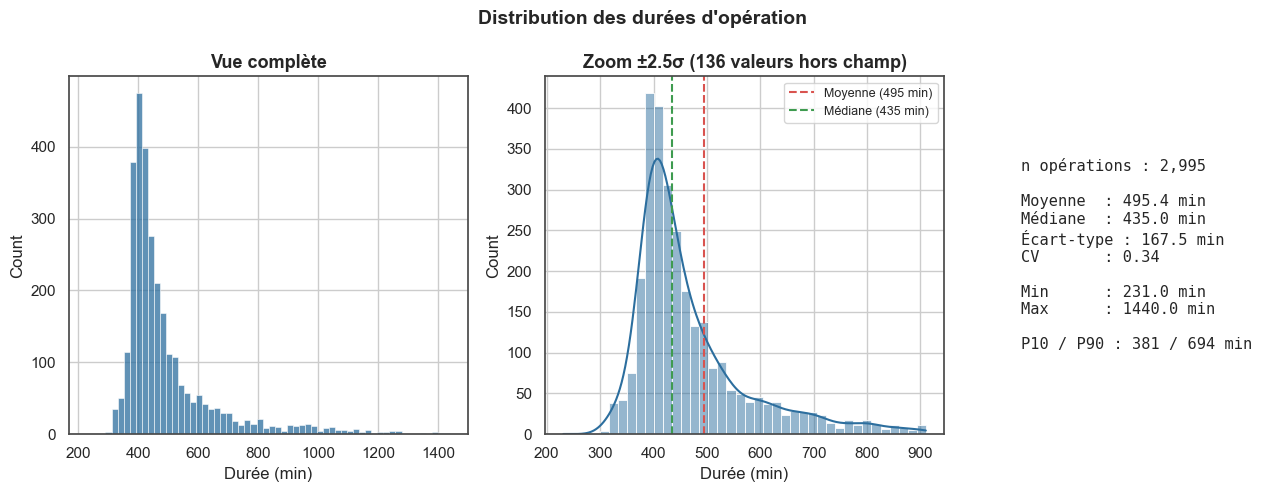

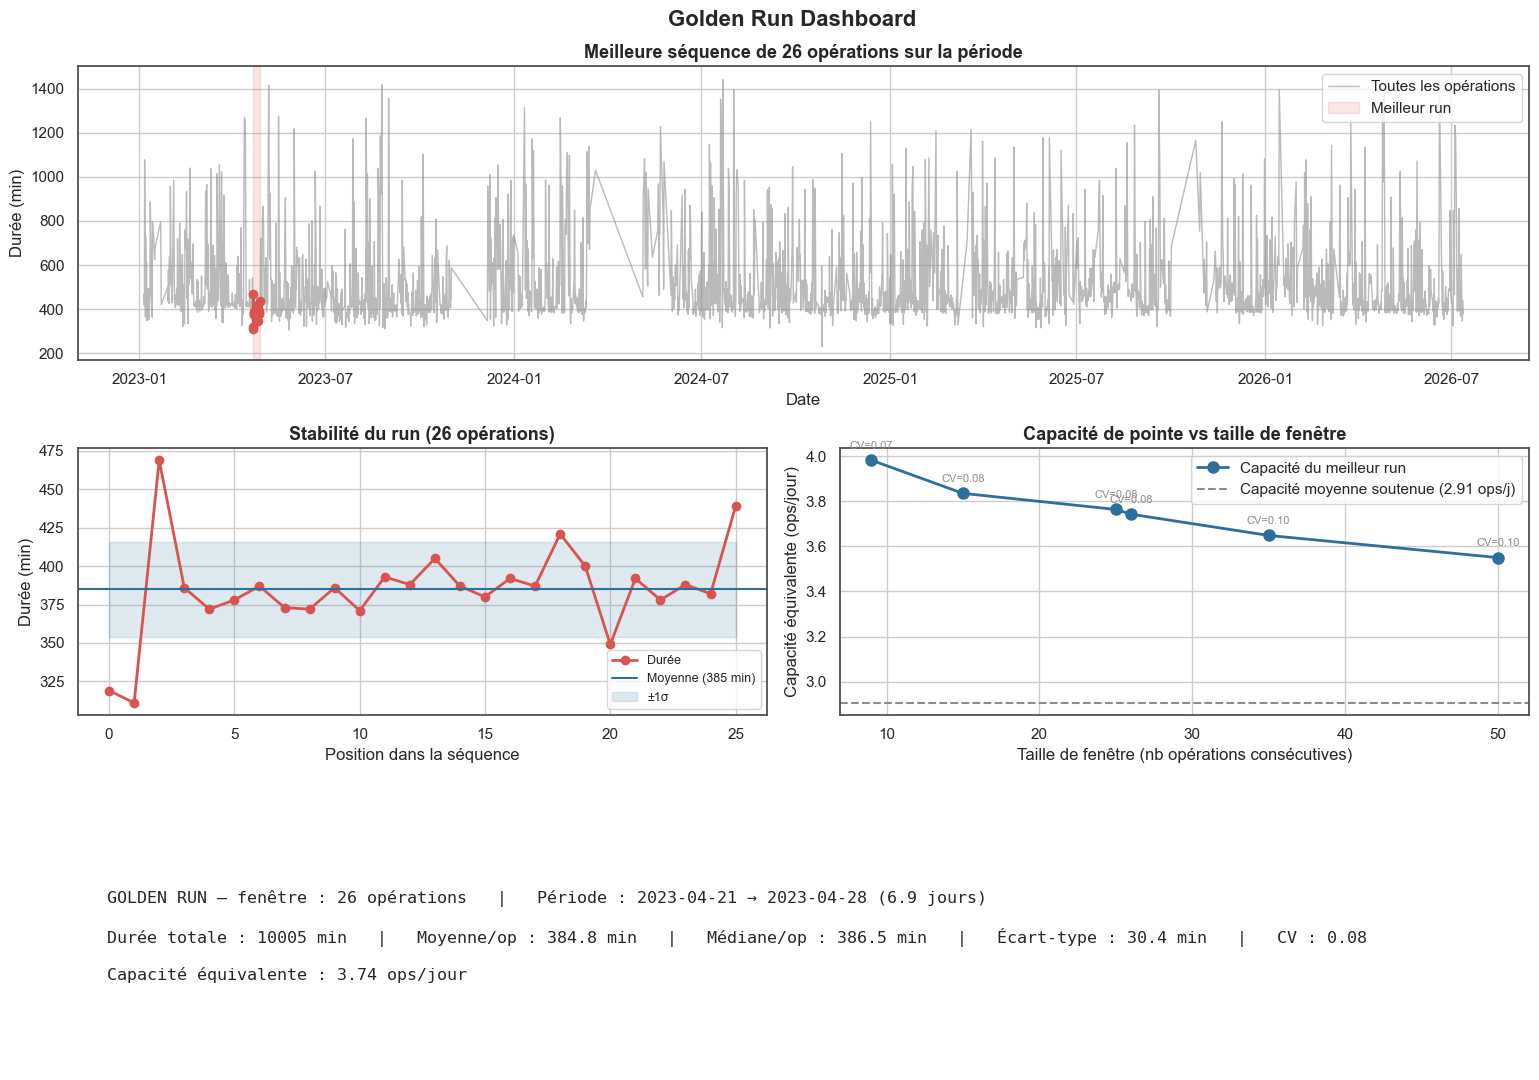

### Résultats

- Nombre d'opérations analysées : **2,995**
- Durée moyenne : **495.4 min** (8.26 h)
- Durée médiane : **435.0 min**
- Durée min / max : **231.0 min** / **1440.0 min**
- Écart-type : **167.5 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3255.0 min au total (2023-07-20 16:36 → 2023-07-22 22:51) → capacité équivalente **3.98 ops/jour**
- Fenêtre de 15 opérations : 5633.0 min au total (2023-07-20 16:36 → 2023-07-24 14:29) → capacité équivalente **3.83 ops/jour**
- Fenêtre de 25 opérations : 9566.0 min au total (2023-04-21 11:06 → 2023-04-28 02:32) → capacité équivalente **3.76 ops/jour**
- Fenêtre de 26 opérations : 10005.0 min au total (2023-04-21 11:06 → 2023-04-28 09:51) → capacité équivalente **3.74 ops/jour**
- Fenêtre de 35 opérations : 13815.0 min au total (2023-04-18 12:17 → 2023-04-28 02:32) → capacité équivalente **3.65 ops/jour**
- Fenêtre de 50 opérations : 20281.0 min au total (2023-04-14 22:29 → 2023-04-29 00:30) → capacité équivalente **3.55 ops/jour**

**Golden run** (fenêtre de référence : 26 opérations) : capacité équivalente **3.74 ops/jour**, sur **6.9 jours**, coefficient de variation **0.08**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.4%** — proches, run homogène.
- La fenêtre de 26 opérations couvre **6.9 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : dégradation (pente = -0.0045 / mois)
**Écart au record (score, indicateur secondaire)** : dégradation (pente = -0.0006 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2023-07** (score = 0.841)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.501)

### Interprétation

Le z-score indique une **dégradation** de la performance dans le temps — à surveiller.

### NOP_ESTERS — Nombre des opérations

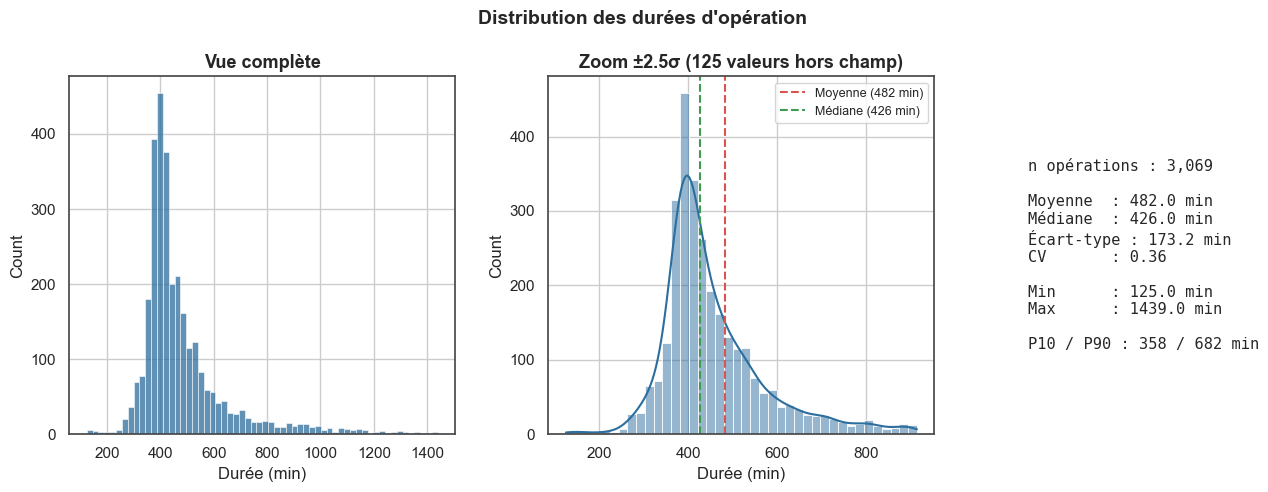

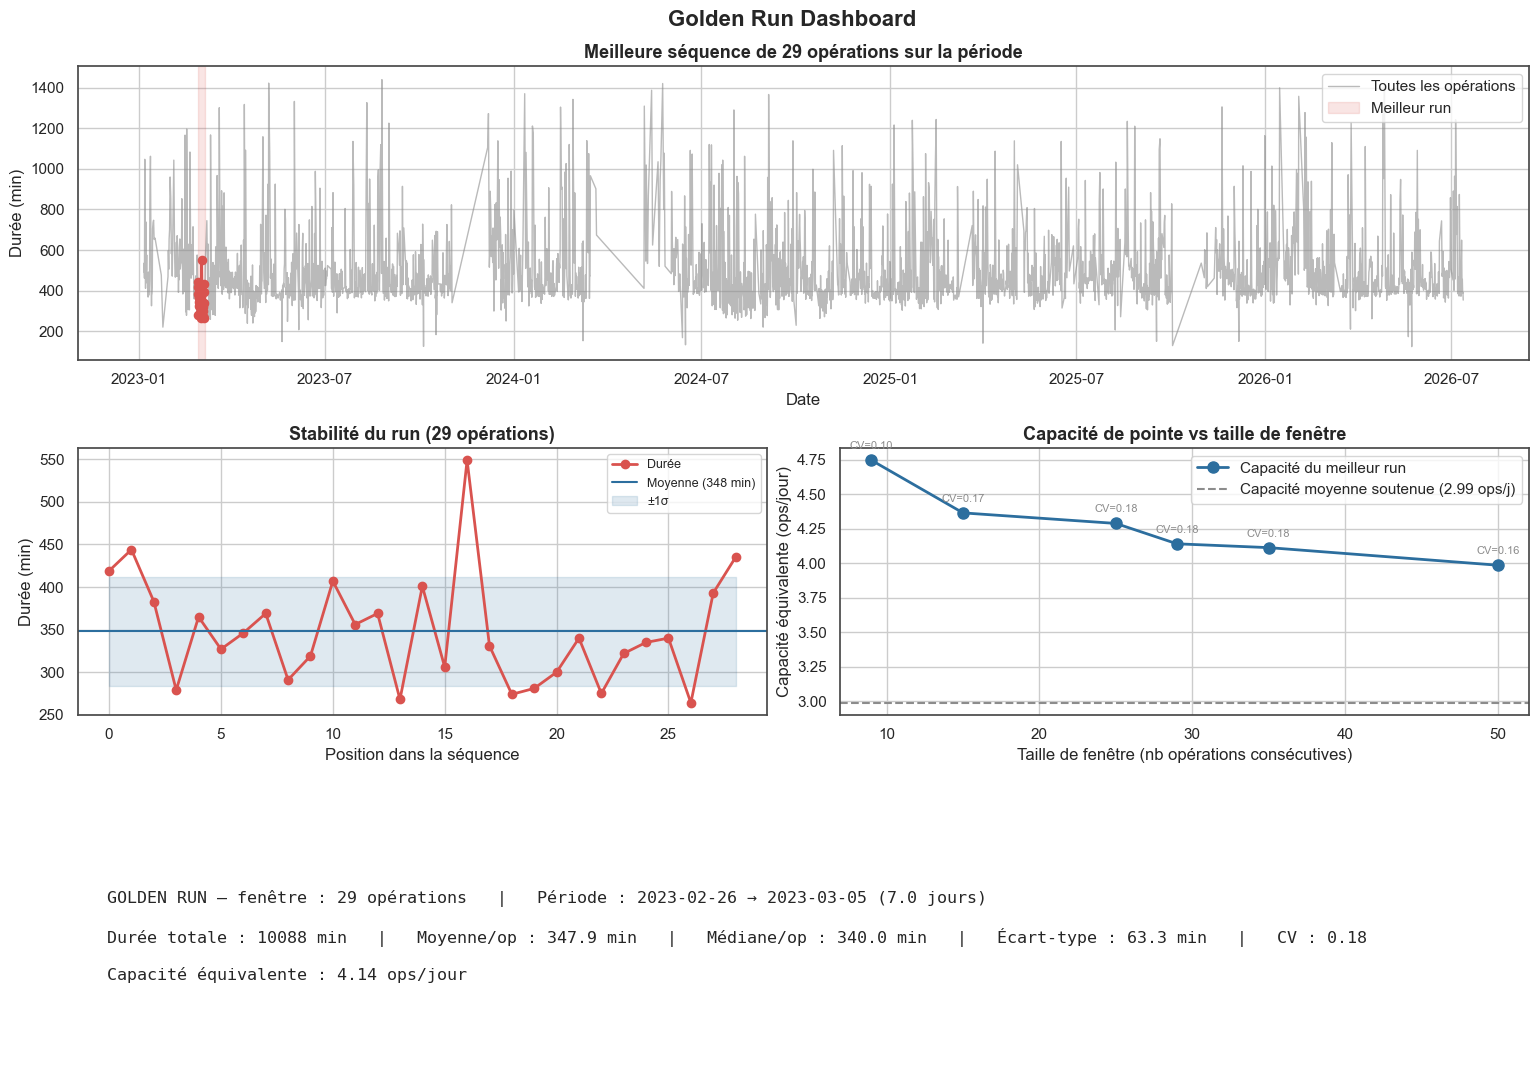

### Résultats

- Nombre d'opérations analysées : **3,069**
- Durée moyenne : **482.0 min** (8.03 h)
- Durée médiane : **426.0 min**
- Durée min / max : **125.0 min** / **1439.0 min**
- Écart-type : **173.2 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 2731.0 min au total (2023-03-03 11:49 → 2023-03-05 09:20) → capacité équivalente **4.75 ops/jour**
- Fenêtre de 15 opérations : 4950.0 min au total (2023-04-21 19:11 → 2023-04-25 05:41) → capacité équivalente **4.36 ops/jour**
- Fenêtre de 25 opérations : 8397.0 min au total (2023-02-27 13:23 → 2023-03-05 09:20) → capacité équivalente **4.29 ops/jour**
- Fenêtre de 29 opérations : 10088.0 min au total (2023-02-26 23:00 → 2023-03-05 23:08) → capacité équivalente **4.14 ops/jour**
- Fenêtre de 35 opérations : 12257.0 min au total (2023-04-16 10:18 → 2023-04-24 22:35) → capacité équivalente **4.11 ops/jour**
- Fenêtre de 50 opérations : 18070.0 min au total (2023-04-15 08:39 → 2023-04-27 21:49) → capacité équivalente **3.98 ops/jour**

**Golden run** (fenêtre de référence : 29 opérations) : capacité équivalente **4.14 ops/jour**, sur **7.0 jours**, coefficient de variation **0.18**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **2.3%** — proches, run homogène.
- La fenêtre de 29 opérations couvre **7.0 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run modérément hétérogène (0.15 ≤ CV < 0.30) : comparer moyenne et médiane avant de trancher.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : amélioration (pente = +0.0057 / mois)
**Écart au record (score, indicateur secondaire)** : dégradation (pente = -0.0000 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2023-04** (score = 0.739)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.384)

### Interprétation

Le z-score indique une **amélioration** de la performance dans le temps.

### NOP_RETINOL — Nombre des opérations

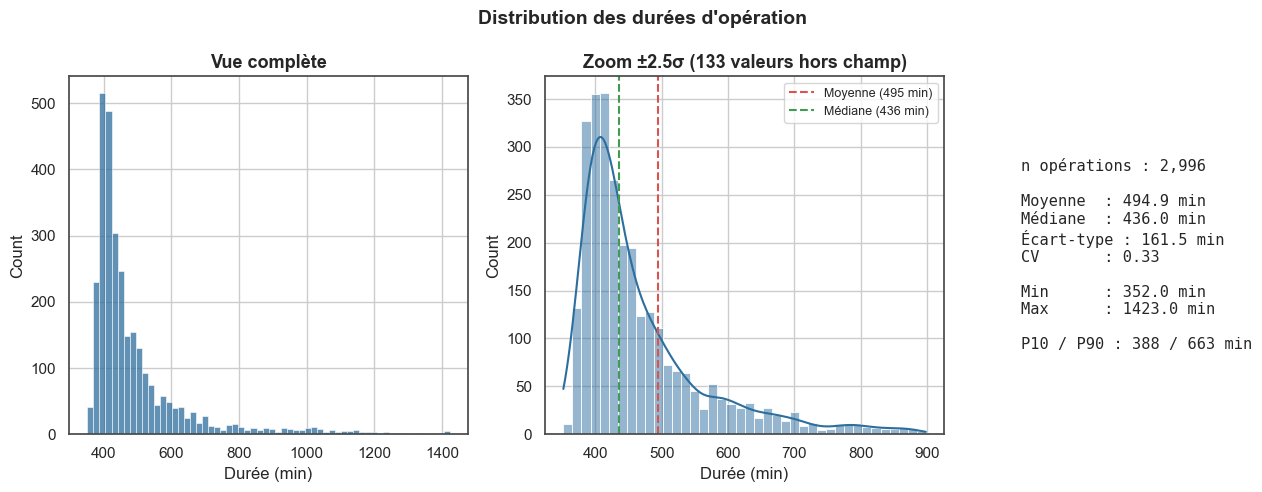

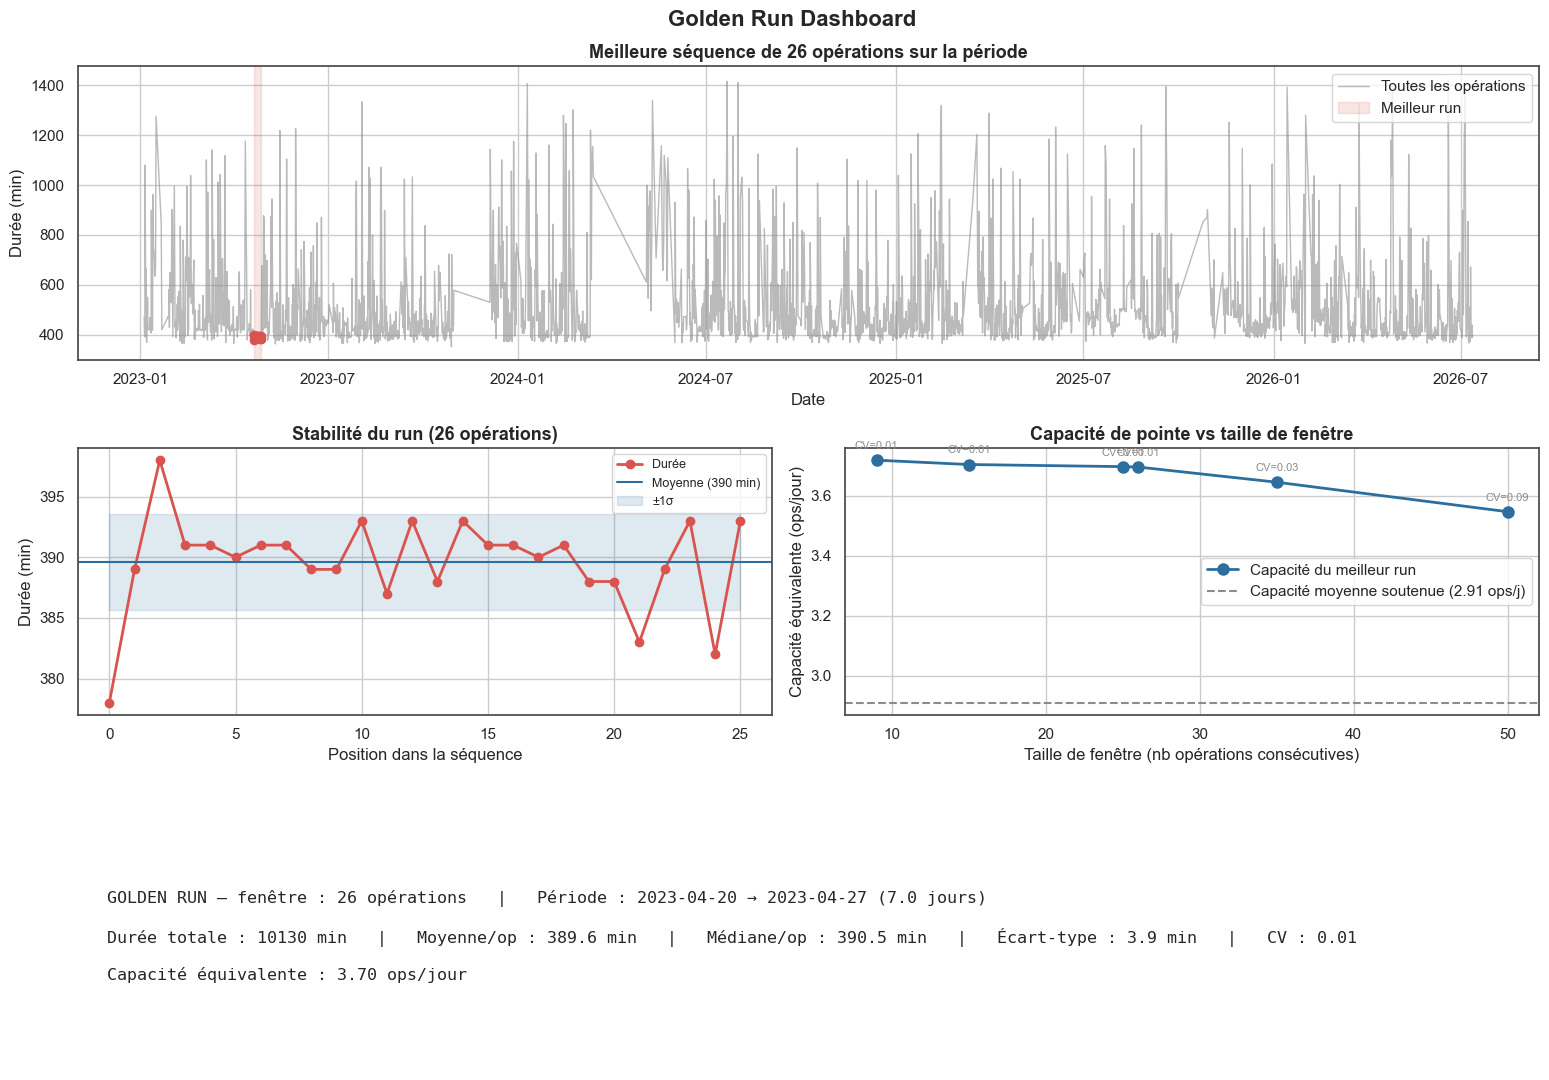

### Résultats

- Nombre d'opérations analysées : **2,996**
- Durée moyenne : **494.9 min** (8.25 h)
- Durée médiane : **436.0 min**
- Durée min / max : **352.0 min** / **1423.0 min**
- Écart-type : **161.5 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3485.0 min au total (2023-04-25 16:29 → 2023-04-28 02:34) → capacité équivalente **3.72 ops/jour**
- Fenêtre de 15 opérations : 5831.0 min au total (2023-04-24 01:23 → 2023-04-28 02:34) → capacité équivalente **3.70 ops/jour**
- Fenêtre de 25 opérations : 9737.0 min au total (2023-04-20 19:26 → 2023-04-27 13:43) → capacité équivalente **3.70 ops/jour**
- Fenêtre de 26 opérations : 10130.0 min au total (2023-04-20 19:26 → 2023-04-27 20:16) → capacité équivalente **3.70 ops/jour**
- Fenêtre de 35 opérations : 13826.0 min au total (2023-04-18 12:08 → 2023-04-28 02:34) → capacité équivalente **3.65 ops/jour**
- Fenêtre de 50 opérations : 20299.0 min au total (2023-04-14 09:09 → 2023-04-28 11:28) → capacité équivalente **3.55 ops/jour**

**Golden run** (fenêtre de référence : 26 opérations) : capacité équivalente **3.70 ops/jour**, sur **7.0 jours**, coefficient de variation **0.01**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.2%** — proches, run homogène.
- La fenêtre de 26 opérations couvre **7.0 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : dégradation (pente = -0.0034 / mois)
**Écart au record (score, indicateur secondaire)** : dégradation (pente = -0.0006 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2023-07** (score = 0.889)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.516)

### Interprétation

Le z-score indique une **dégradation** de la performance dans le temps — à surveiller.

### NOP_RHQ — Nombre des opérations

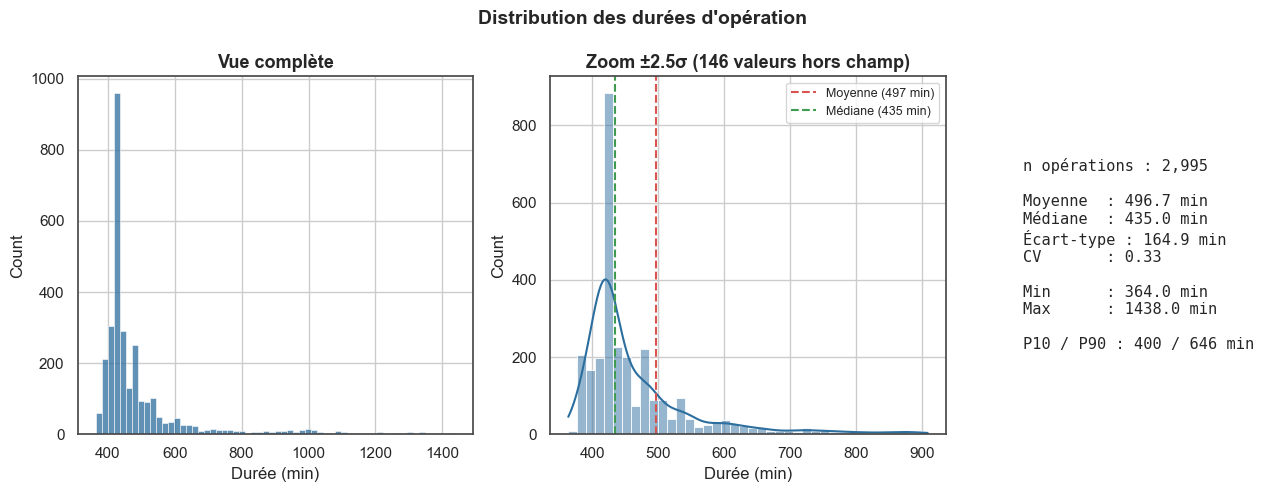

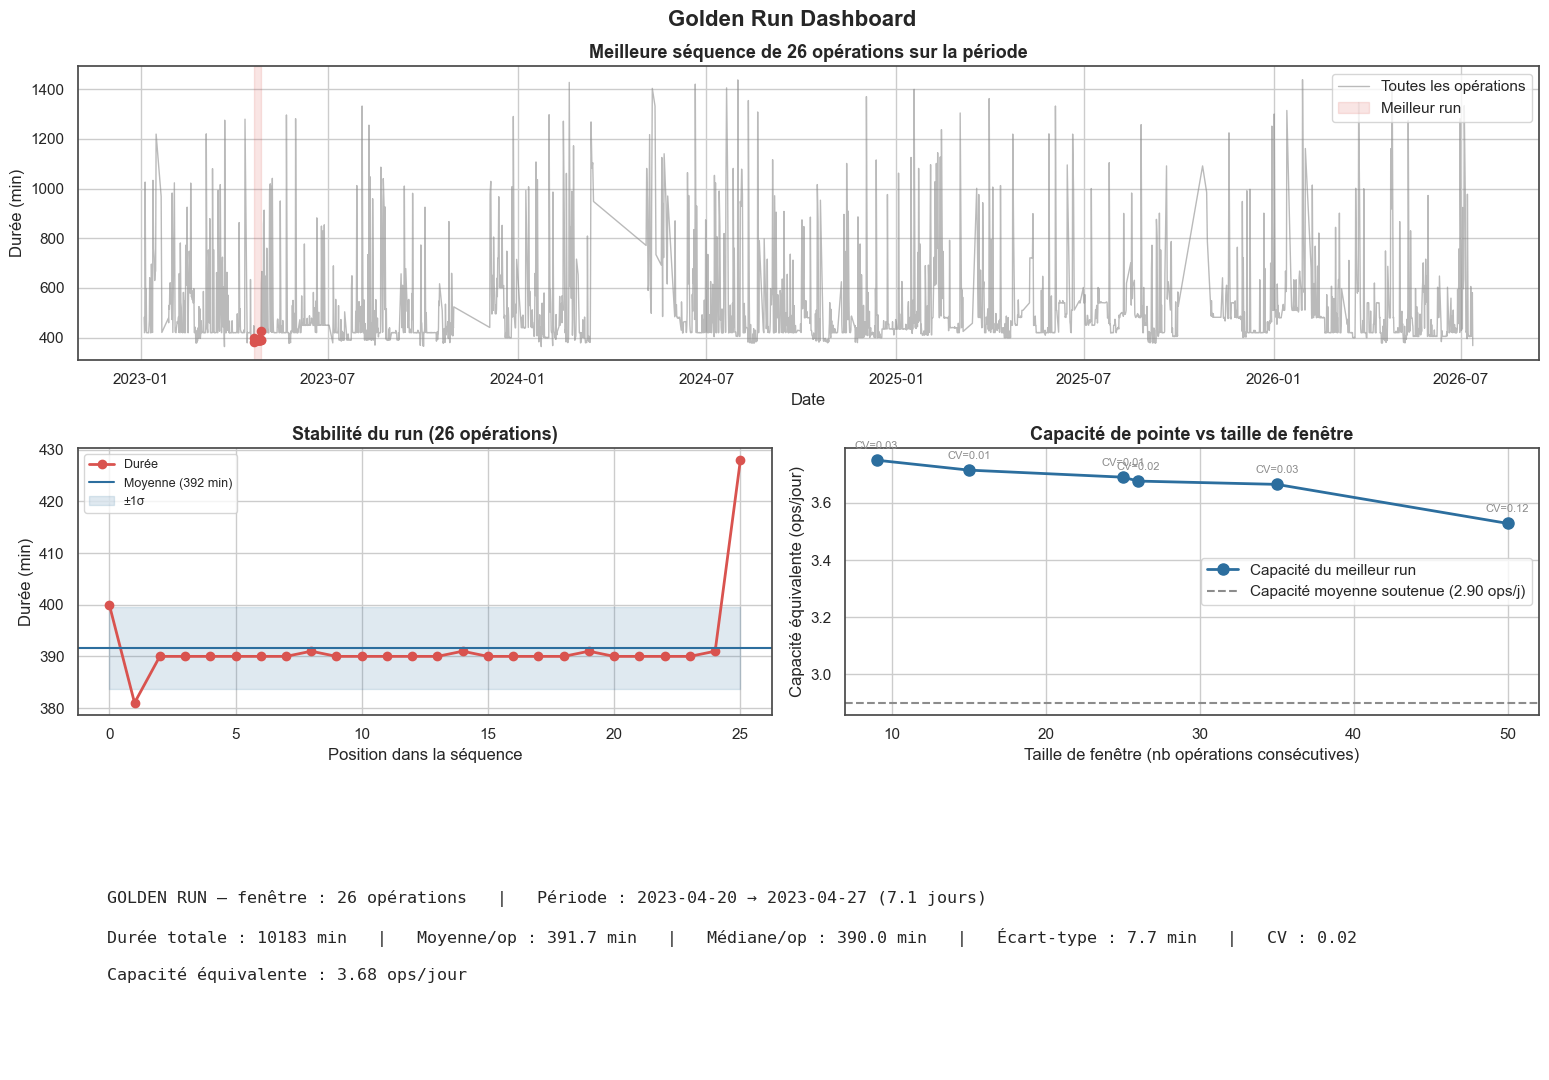

### Résultats

- Nombre d'opérations analysées : **2,995**
- Durée moyenne : **496.7 min** (8.28 h)
- Durée médiane : **435.0 min**
- Durée min / max : **364.0 min** / **1438.0 min**
- Écart-type : **164.9 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3456.0 min au total (2024-08-13 12:54 → 2024-08-15 22:30) → capacité équivalente **3.75 ops/jour**
- Fenêtre de 15 opérations : 5814.0 min au total (2024-10-23 21:01 → 2024-10-27 21:55) → capacité équivalente **3.72 ops/jour**
- Fenêtre de 25 opérations : 9755.0 min au total (2023-04-20 16:31 → 2023-04-27 11:06) → capacité équivalente **3.69 ops/jour**
- Fenêtre de 26 opérations : 10183.0 min au total (2023-04-20 16:31 → 2023-04-27 18:14) → capacité équivalente **3.68 ops/jour**
- Fenêtre de 35 opérations : 13751.0 min au total (2023-04-17 15:24 → 2023-04-27 04:35) → capacité équivalente **3.67 ops/jour**
- Fenêtre de 50 opérations : 20406.0 min au total (2023-04-14 00:28 → 2023-04-28 04:34) → capacité équivalente **3.53 ops/jour**

**Golden run** (fenêtre de référence : 26 opérations) : capacité équivalente **3.68 ops/jour**, sur **7.1 jours**, coefficient de variation **0.02**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.4%** — proches, run homogène.
- La fenêtre de 26 opérations couvre **7.1 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : dégradation (pente = -0.0020 / mois)
**Écart au record (score, indicateur secondaire)** : dégradation (pente = -0.0005 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2023-07** (score = 0.886)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.511)

### Interprétation

Le z-score indique une **dégradation** de la performance dans le temps — à surveiller.

### NOP_RETINENE — Nombre des opérations

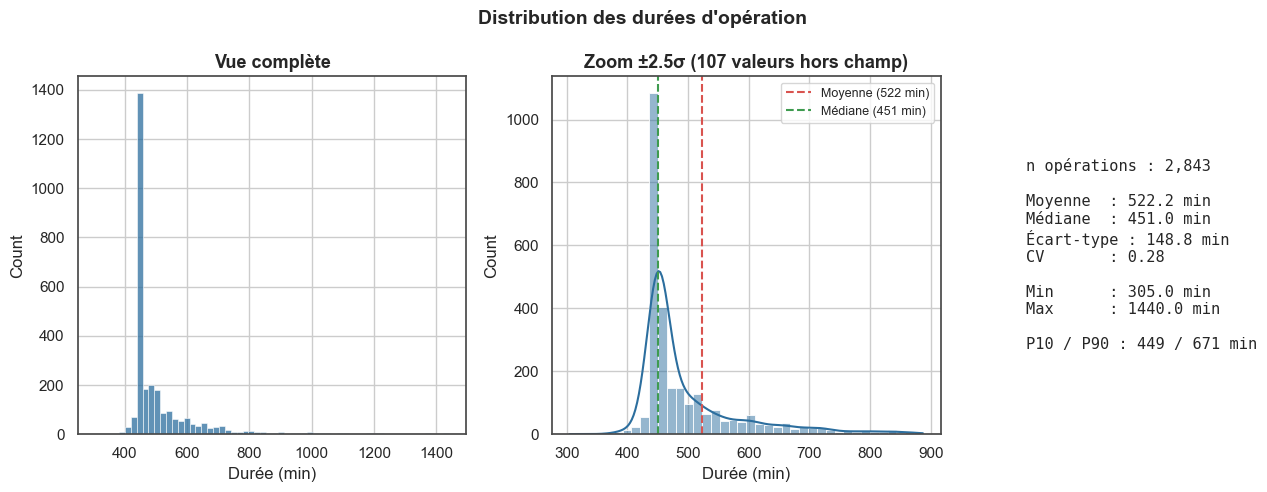

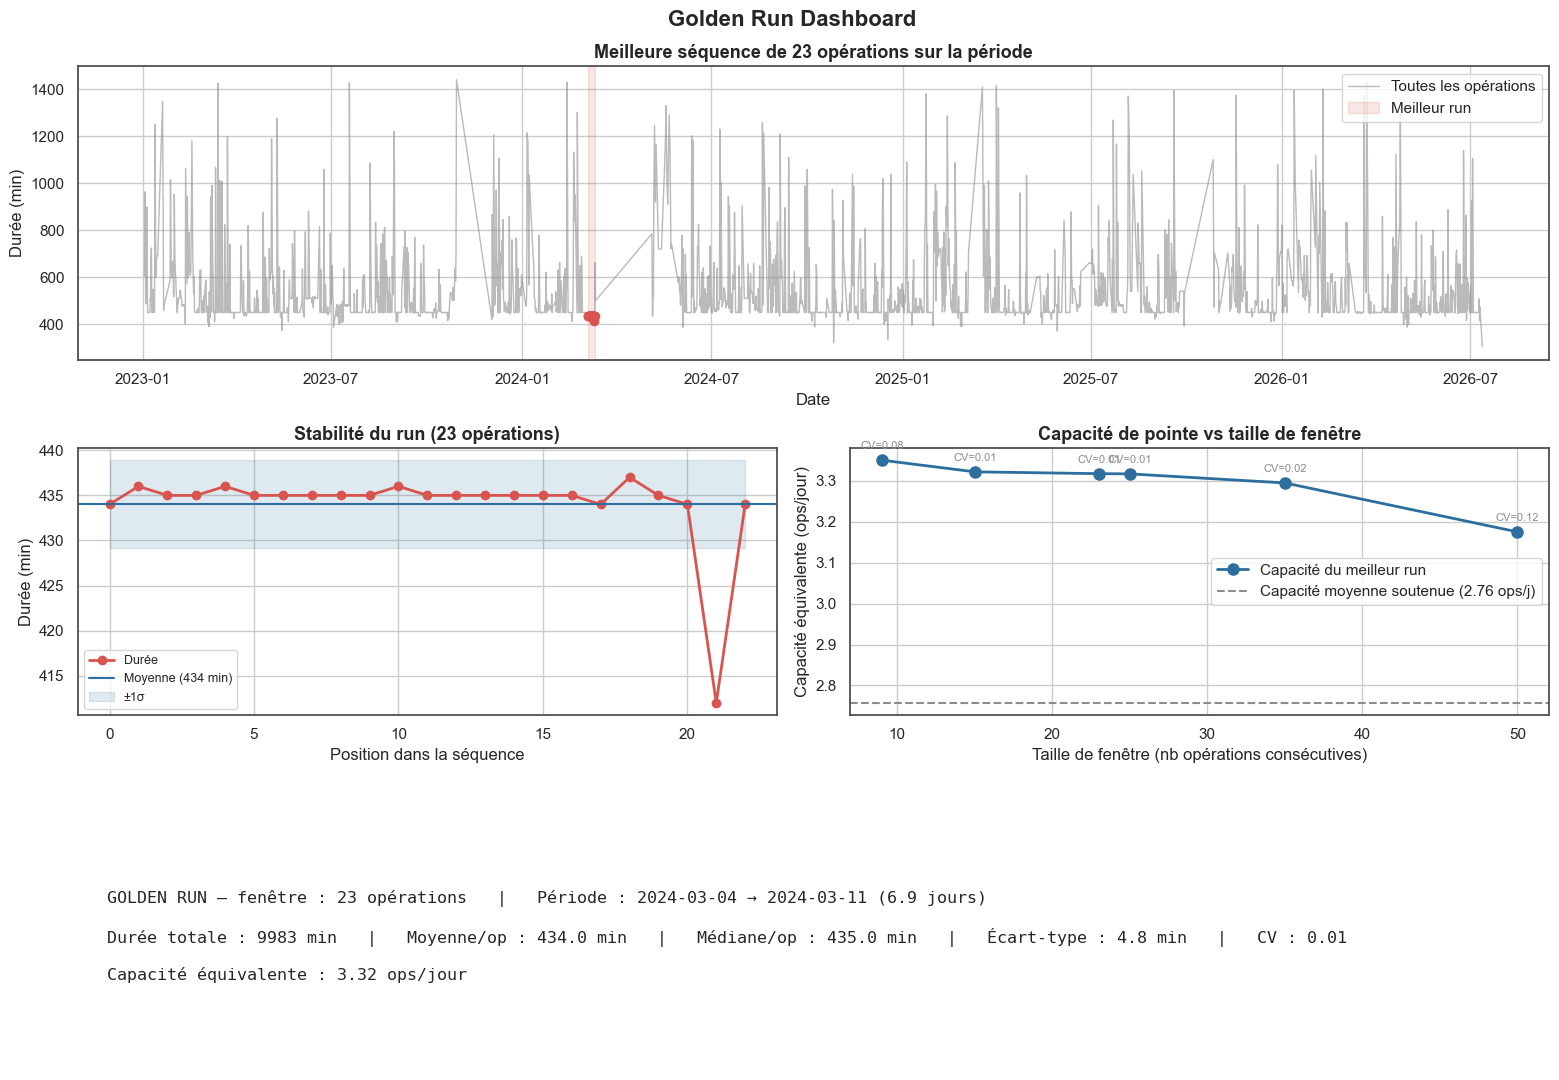

### Résultats

- Nombre d'opérations analysées : **2,843**
- Durée moyenne : **522.2 min** (8.70 h)
- Durée médiane : **451.0 min**
- Durée min / max : **305.0 min** / **1440.0 min**
- Écart-type : **148.8 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3868.0 min au total (2024-12-15 02:48 → 2024-12-17 19:16) → capacité équivalente **3.35 ops/jour**
- Fenêtre de 15 opérations : 6502.0 min au total (2024-03-06 12:03 → 2024-03-11 00:25) → capacité équivalente **3.32 ops/jour**
- Fenêtre de 23 opérations : 9983.0 min au total (2024-03-04 02:02 → 2024-03-11 00:25) → capacité équivalente **3.32 ops/jour**
- Fenêtre de 25 opérations : 10853.0 min au total (2024-03-03 11:32 → 2024-03-11 00:25) → capacité équivalente **3.32 ops/jour**
- Fenêtre de 35 opérations : 15296.0 min au total (2024-02-29 09:29 → 2024-03-11 00:25) → capacité équivalente **3.29 ops/jour**
- Fenêtre de 50 opérations : 22675.0 min au total (2024-02-24 06:30 → 2024-03-11 00:25) → capacité équivalente **3.18 ops/jour**

**Golden run** (fenêtre de référence : 23 opérations) : capacité équivalente **3.32 ops/jour**, sur **6.9 jours**, coefficient de variation **0.01**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.2%** — proches, run homogène.
- La fenêtre de 23 opérations couvre **6.9 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : amélioration (pente = +0.0038 / mois)
**Écart au record (score, indicateur secondaire)** : amélioration (pente = +0.0002 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2024-03** (score = 0.931)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.565)

### Interprétation

Le z-score indique une **amélioration** de la performance dans le temps.

### NOP_SC15 — Nombre des opérations

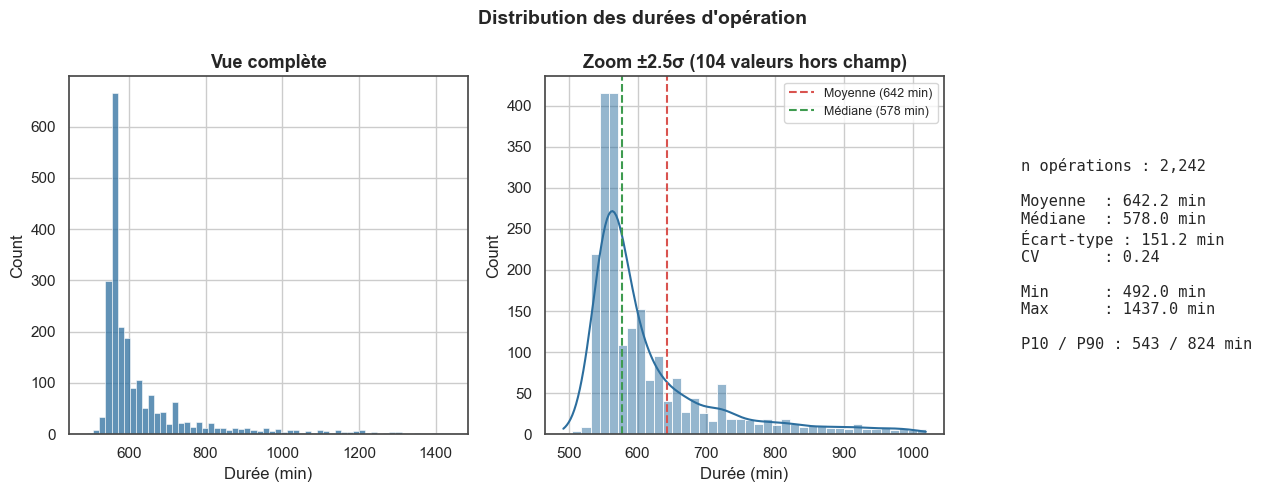

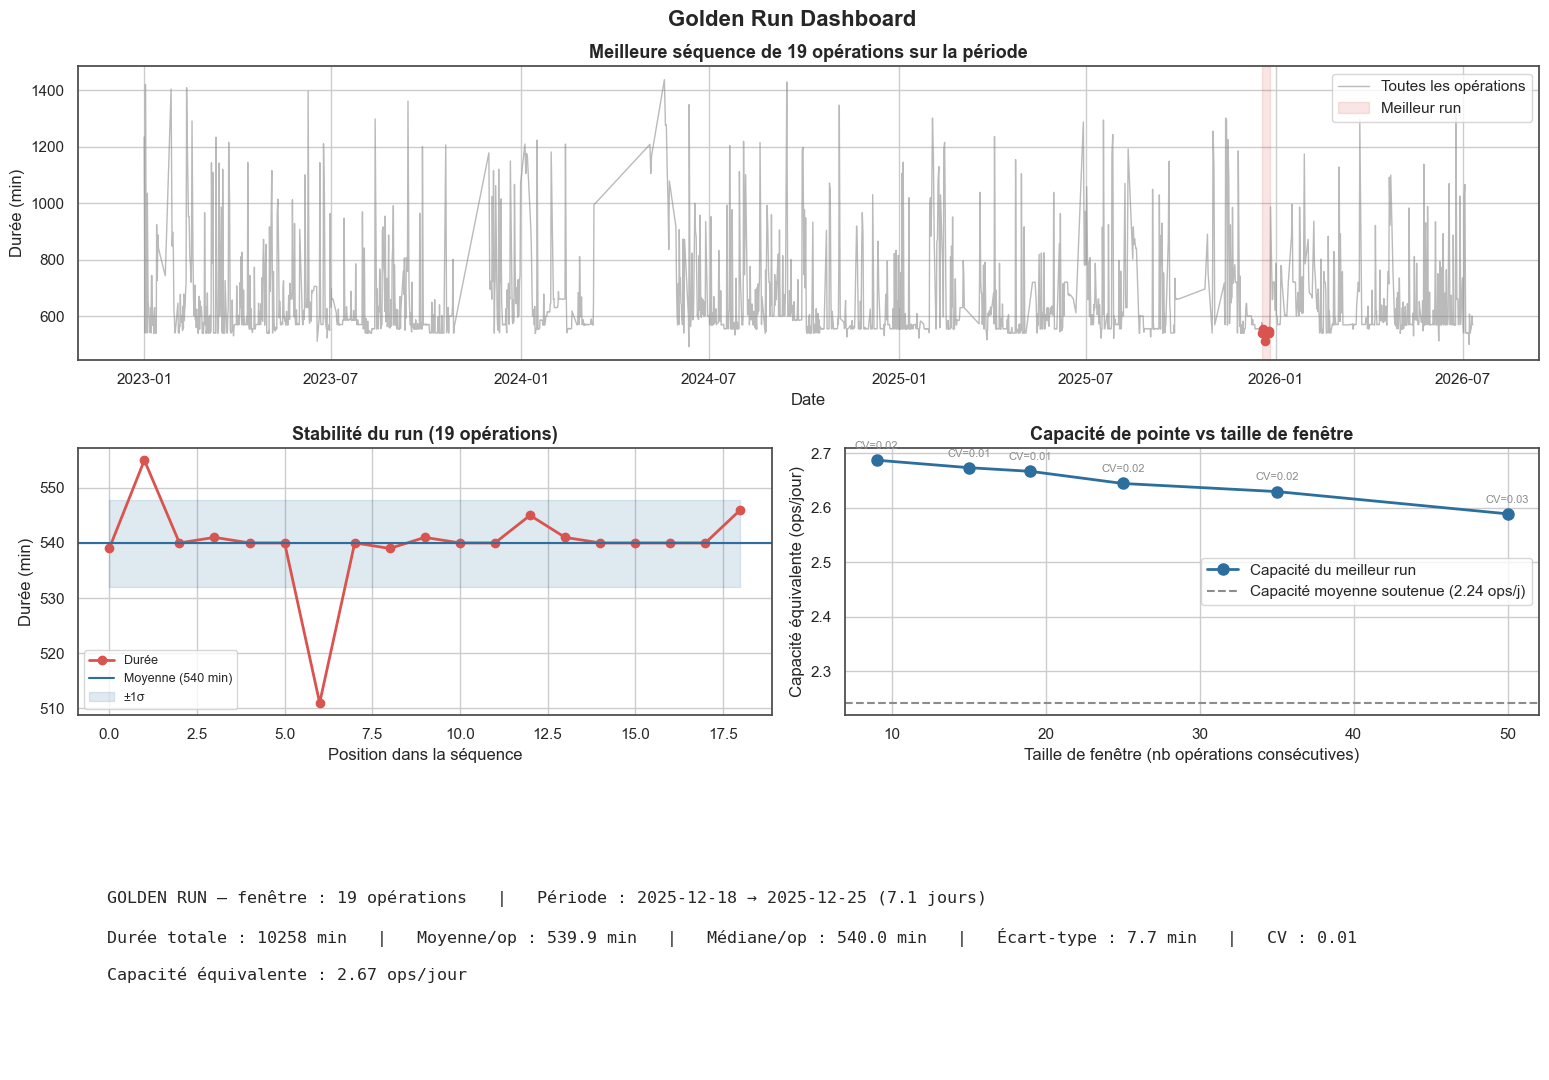

### Résultats

- Nombre d'opérations analysées : **2,242**
- Durée moyenne : **642.2 min** (10.70 h)
- Durée médiane : **578.0 min**
- Durée min / max : **492.0 min** / **1437.0 min**
- Écart-type : **151.2 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 4822.0 min au total (2026-07-03 21:31 → 2026-07-07 05:53) → capacité équivalente **2.69 ops/jour**
- Fenêtre de 15 opérations : 8078.0 min au total (2025-12-19 08:59 → 2025-12-24 23:37) → capacité équivalente **2.67 ops/jour**
- Fenêtre de 19 opérations : 10258.0 min au total (2025-12-18 14:45 → 2025-12-25 17:43) → capacité équivalente **2.67 ops/jour**
- Fenêtre de 25 opérations : 13611.0 min au total (2025-12-16 06:52 → 2025-12-25 17:43) → capacité équivalente **2.64 ops/jour**
- Fenêtre de 35 opérations : 19163.0 min au total (2025-12-12 10:20 → 2025-12-25 17:43) → capacité équivalente **2.63 ops/jour**
- Fenêtre de 50 opérations : 27808.0 min au total (2025-12-06 19:35 → 2025-12-26 03:03) → capacité équivalente **2.59 ops/jour**

**Golden run** (fenêtre de référence : 19 opérations) : capacité équivalente **2.67 ops/jour**, sur **7.1 jours**, coefficient de variation **0.01**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.0%** — proches, run homogène.
- La fenêtre de 19 opérations couvre **7.1 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : amélioration (pente = +0.0076 / mois)
**Écart au record (score, indicateur secondaire)** : amélioration (pente = +0.0006 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2026-07** (score = 0.942)
- Mois le plus faible (score moyen) : **2025-10** (score = 0.645)

### Interprétation

Le z-score indique une **amélioration** de la performance dans le temps.

### OP1510VA_CPT — Nombre des opérations

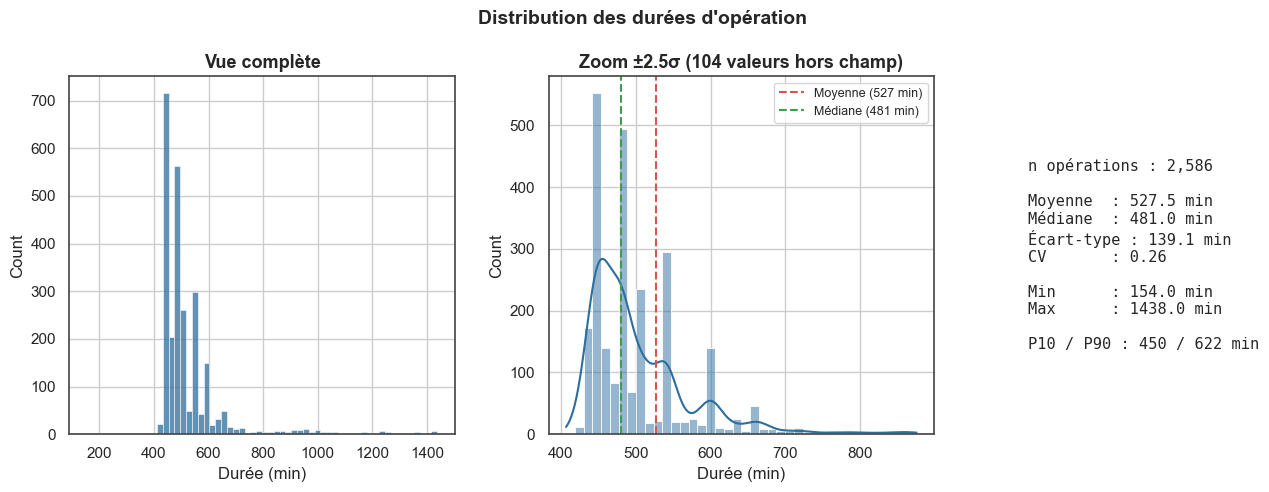

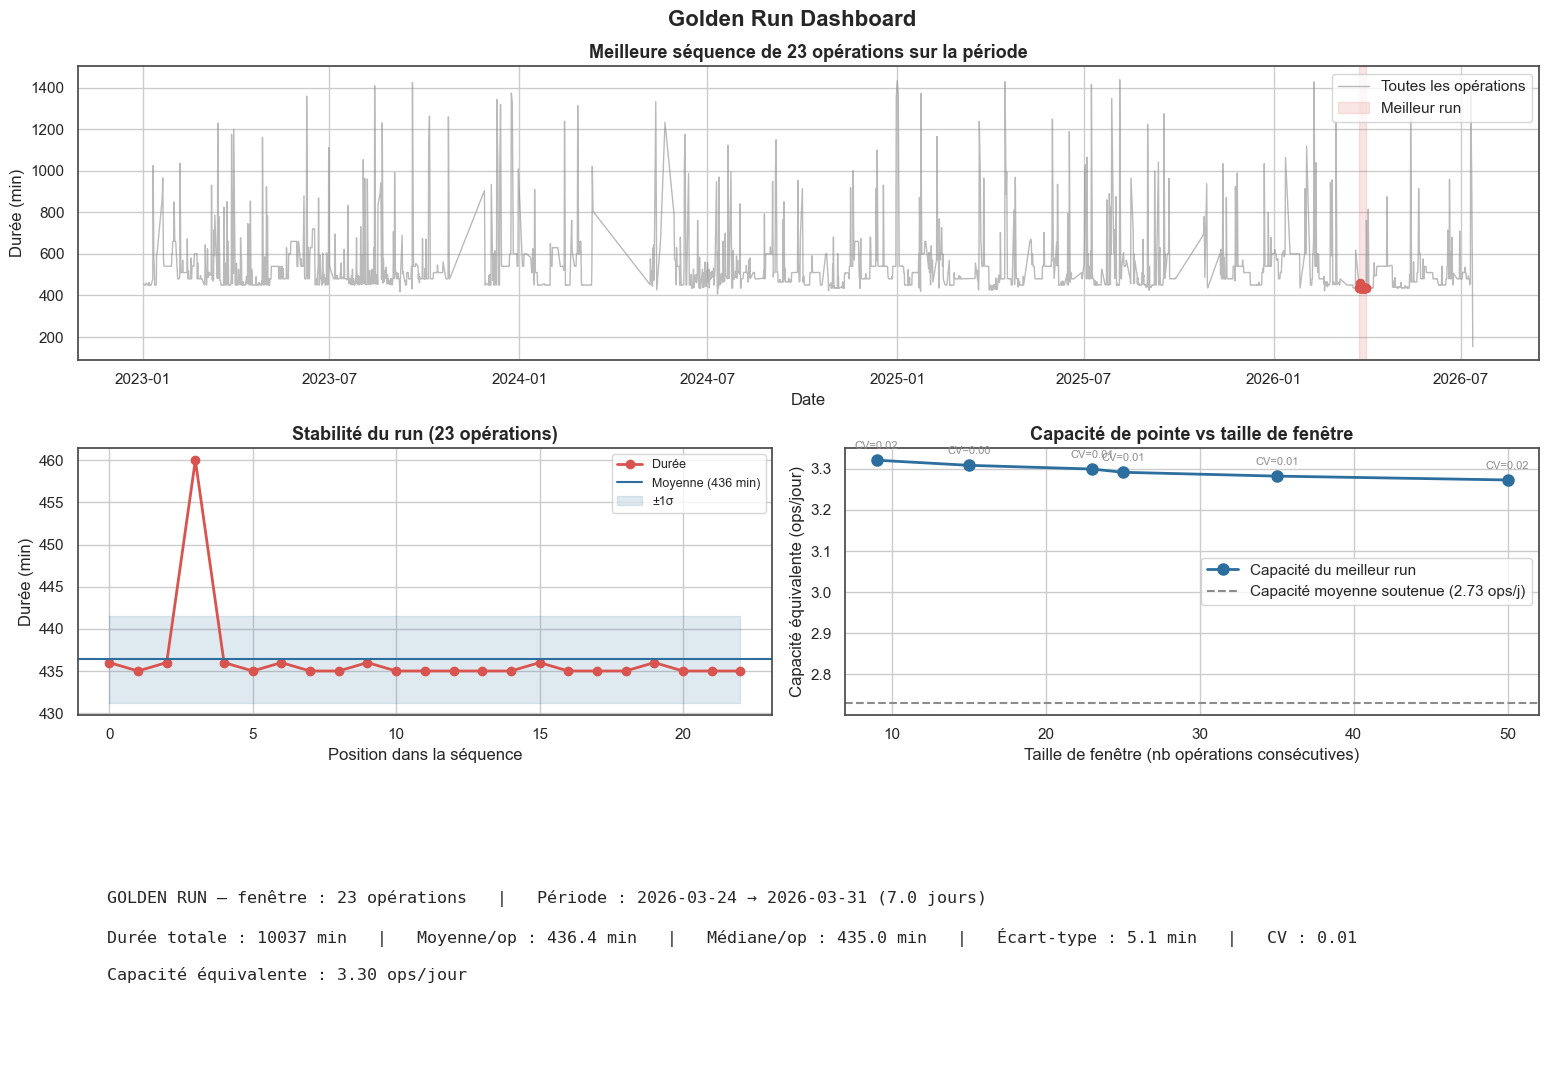

### Résultats

- Nombre d'opérations analysées : **2,586**
- Durée moyenne : **527.5 min** (8.79 h)
- Durée médiane : **481.0 min**
- Durée min / max : **154.0 min** / **1438.0 min**
- Écart-type : **139.1 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 3902.0 min au total (2025-03-31 02:06 → 2025-04-03 19:16) → capacité équivalente **3.32 ops/jour**
- Fenêtre de 15 opérations : 6528.0 min au total (2026-03-26 19:10 → 2026-03-31 07:58) → capacité équivalente **3.31 ops/jour**
- Fenêtre de 23 opérations : 10037.0 min au total (2026-03-24 15:56 → 2026-03-31 15:13) → capacité équivalente **3.30 ops/jour**
- Fenêtre de 25 opérations : 10936.0 min au total (2026-05-04 22:02 → 2026-05-12 12:18) → capacité équivalente **3.29 ops/jour**
- Fenêtre de 35 opérations : 15354.0 min au total (2026-05-01 20:24 → 2026-05-12 12:18) → capacité équivalente **3.28 ops/jour**
- Fenêtre de 50 opérations : 21997.0 min au total (2026-04-27 05:41 → 2026-05-12 12:18) → capacité équivalente **3.27 ops/jour**

**Golden run** (fenêtre de référence : 23 opérations) : capacité équivalente **3.30 ops/jour**, sur **7.0 jours**, coefficient de variation **0.01**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **0.3%** — proches, run homogène.
- La fenêtre de 23 opérations couvre **7.0 jours**, proche d'une semaine : maille hebdomadaire cohérente pour un suivi OEE.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : amélioration (pente = +0.0121 / mois)
**Écart au record (score, indicateur secondaire)** : amélioration (pente = +0.0007 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2026-03** (score = 0.945)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.715)

### Interprétation

Le z-score indique une **amélioration** de la performance dans le temps.

### NOP_AOIP — Nombre des opérations

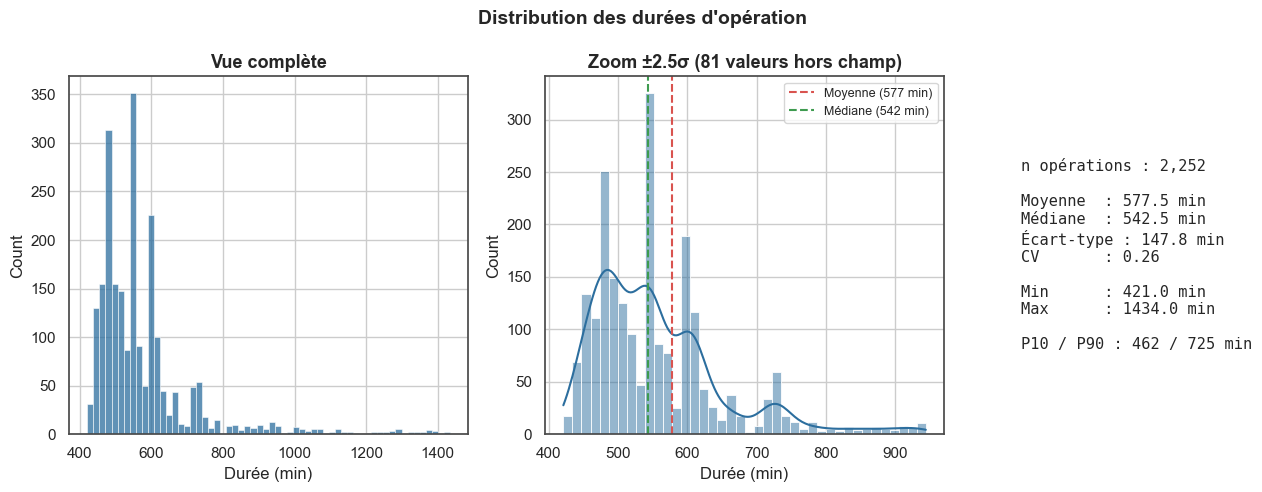

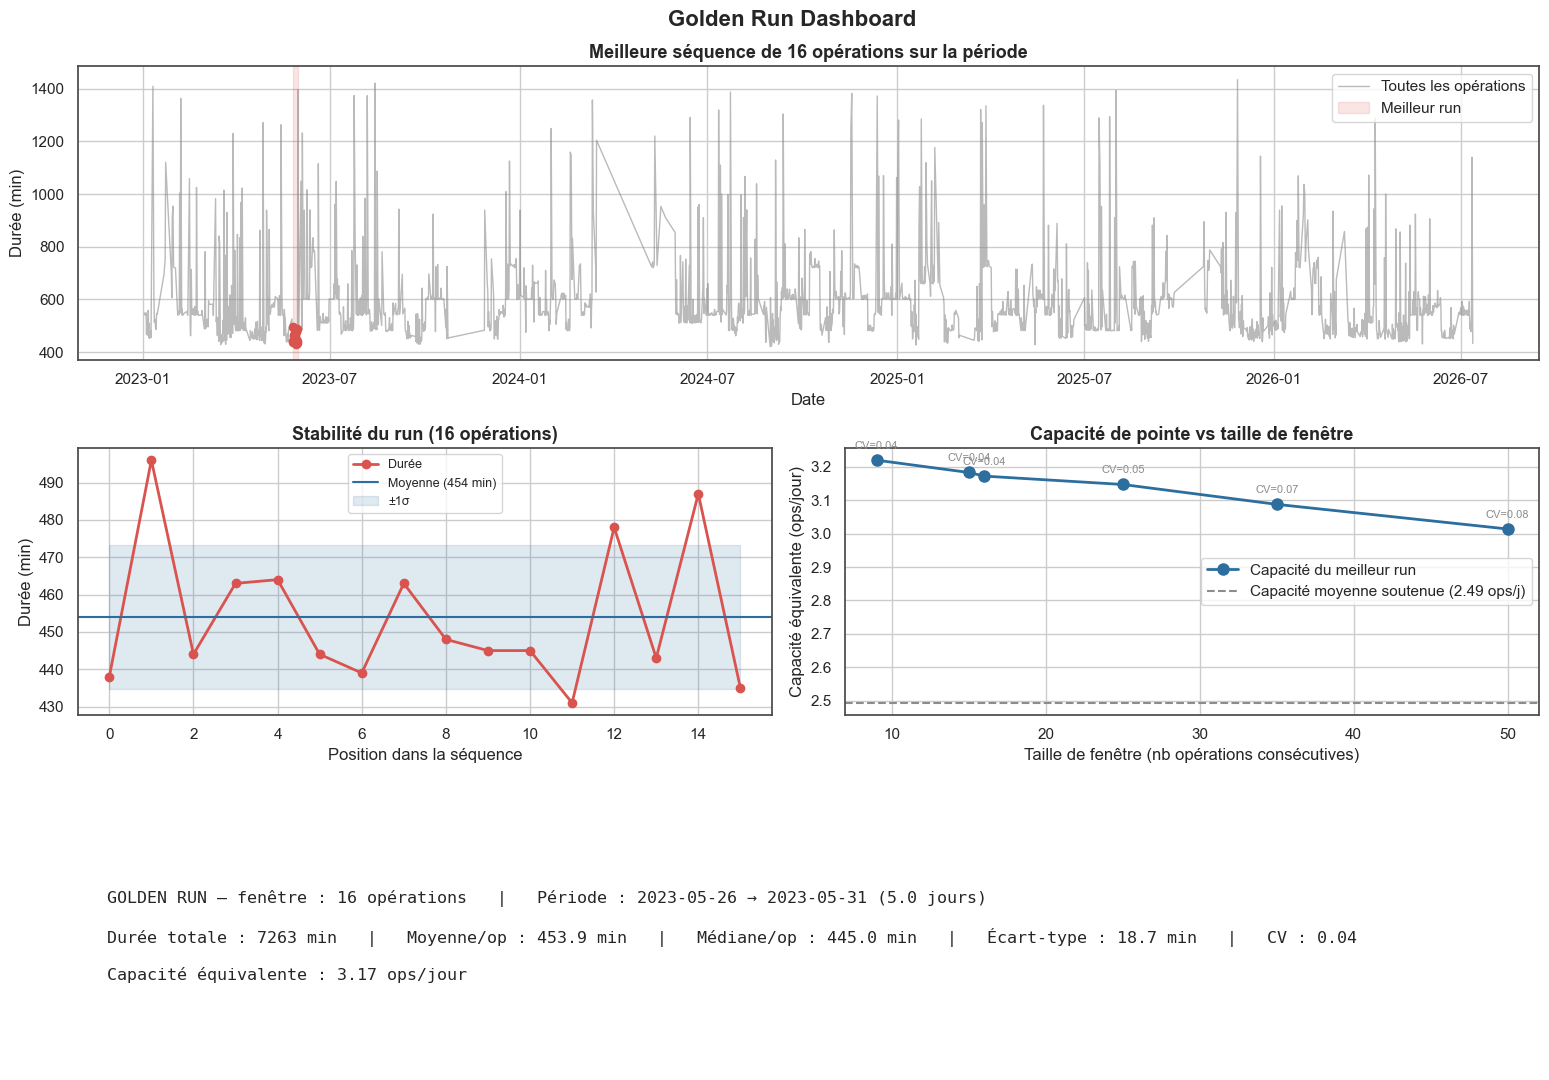

### Résultats

- Nombre d'opérations analysées : **2,252**
- Durée moyenne : **577.5 min** (9.62 h)
- Durée médiane : **542.5 min**
- Durée min / max : **421.0 min** / **1434.0 min**
- Écart-type : **147.8 min**

**Meilleures séries consécutives :**

- Fenêtre de 9 opérations : 4025.0 min au total (2023-03-17 02:32 → 2023-03-19 21:37) → capacité équivalente **3.22 ops/jour**
- Fenêtre de 15 opérations : 6786.0 min au total (2023-05-25 20:07 → 2023-05-30 13:13) → capacité équivalente **3.18 ops/jour**
- Fenêtre de 16 opérations : 7263.0 min au total (2023-05-26 03:32 → 2023-05-31 04:35) → capacité équivalente **3.17 ops/jour**
- Fenêtre de 25 opérations : 11439.0 min au total (2023-05-19 14:41 → 2023-05-30 13:13) → capacité équivalente **3.15 ops/jour**
- Fenêtre de 35 opérations : 16323.0 min au total (2023-09-13 14:20 → 2023-09-28 16:46) → capacité équivalente **3.09 ops/jour**
- Fenêtre de 50 opérations : 23889.0 min au total (2023-09-11 20:59 → 2023-10-02 05:31) → capacité équivalente **3.01 ops/jour**

**Golden run** (fenêtre de référence : 16 opérations) : capacité équivalente **3.17 ops/jour**, sur **5.0 jours**, coefficient de variation **0.04**.

### Maille de référence pour l'OEE

- Pour le **débit/capacité**, c'est la **moyenne** qui doit servir de référence (capacité = 1440 / durée moyenne) — la médiane ne reconstitue pas le temps total écoulé.
- Écart moyenne/médiane sur ce run : **2.0%** — proches, run homogène.
- La fenêtre de 16 opérations couvre **5.0 jours** sur ce run — **pas exactement 7 jours** ici : si une maille hebdomadaire est visée, ajuster la taille de fenêtre (`config.GOLDEN_RUN_WINDOW`) plutôt que de supposer que 35 = 7 jours.
- run homogène (CV < 0.15) : moyenne et médiane doivent être proches, référence fiable.
- Aucune opération atypique détectée à l'intérieur du run par rapport à la distribution globale.
- Recommandation générale : le **minimum absolu** est un extrême par construction (référence structurellement optimiste). Pour une référence OEE soutenable, préférer le **10ᵉ percentile** des fenêtres glissantes de même taille (`build_sliding_windows` + `.quantile(0.1)`) plutôt que le record.

### Tendance

**Tendance mensuelle (z-score, indicateur principal)** : amélioration (pente = +0.0081 / mois)
**Écart au record (score, indicateur secondaire)** : amélioration (pente = +0.0008 / mois)

- Période couverte : **2023-01** → **2026-07**
- Meilleur mois (score moyen) : **2025-12** (score = 0.907)
- Mois le plus faible (score moyen) : **2024-05** (score = 0.646)

### Interprétation

Le z-score indique une **amélioration** de la performance dans le temps.

In [10]:
for label, rep in tag_reports.items():
    display(Markdown(f"### {label} — {rep['info']}"))

    plots.plot_duration_histogram(rep['ops'])
    nopa.golden_run_dashboard(rep['ops'], rep['golden'], comparison_window_sizes=config.DEFAULT_WINDOW_SIZES)

    summary_md = nopa.build_summary_report(
        ops=rep['ops'],
        results=rep['comparison_results'],
        golden=rep['golden'],
        monthly_scores=rep['monthly_scores'],
        monthly_zscore=rep['monthly_zscore'],
    )
    display(Markdown(summary_md))


## 7. Conclusions

### Limites

- Le filtre de durée `[config.MIN_OPERATION_DURATION, config.MAX_OPERATION_DURATION]`
  est appliqué uniformément à tous les tags ; si un tag a un profil de durée
  très différent des autres, valider ce seuil spécifiquement pour lui
  (`nopa.duration_threshold_report`, `nopa.short_operations`).
- La fenêtre BDP est ré-estimée indépendamment pour chaque tag : deux tags
  n'ont donc pas nécessairement la même taille de fenêtre de référence, ce
  qui est volontaire (chaque procédé a son propre rythme d'opérations), mais
  rend une comparaison brute du nombre d'opérations entre tags moins
  pertinente qu'une comparaison en ops/jour (Golden Score / TCD).
- Comme pour l'analyse mono-tag, le TCD retenu ici est un **record observé**
  (structurellement optimiste) : pour une référence OEE soutenable dans la
  durée, un percentile (P10) des fenêtres glissantes de même taille reste une
  alternative à envisager (`nopa.build_sliding_windows` + `.quantile(0.1)`).
- Les tags marqués comme écartés (peu de données exploitables) doivent être
  revérifiés une fois plus d'historique disponible.

### Perspectives

- Croiser le Golden Score / TCD par tag avec les volumes réels produits pour
  calculer un OEE complet (Disponibilité × Performance × Qualité).
- Suivre dans le temps la stabilité de la fenêtre BDP estimée par tag (un
  changement brutal de la fenêtre nécessaire pour couvrir 7 jours peut lui
  aussi être un signal de dérive de procédé).


## 8. Génération du rapport PDF (synthèse scientifique)

Cette dernière section assemble, à partir des résultats déjà calculés dans ce
notebook (`tag_reports`, `summary_table`, `compact_table`, `skipped_tags`),
un rapport PDF sobre et scientifique — mise en page proche d'un preprint HAL
(résumé en tête qui énonce directement la conclusion, mots-clés, sections
Introduction / Méthodologie / Résultats / Discussion / Conclusion).

**Dépendances** (déjà installées sur cette machine) : `pandoc` (Markdown →
LaTeX) et `xelatex` (compilation PDF, gère nativement l'UTF-8/le français).
Le gabarit LaTeX sobre est dans `documents/report/hal_template.tex` — à
ajuster librement (police, couleurs, marges) sans toucher au code de
génération ci-dessous.


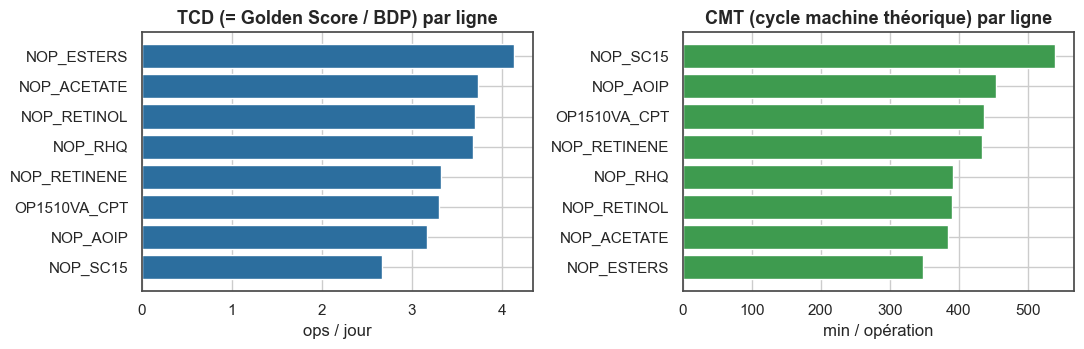

Rapport généré : /Users/rky/Documents/GitHub/Machine-Learning/2-OI_a/documents/report/report.pdf


In [11]:
import subprocess
from pathlib import Path
from datetime import date

REPORT_DIR = Path('documents/report')
FIG_DIR = REPORT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE = "Analyse des performances industrielles de l'atelier Vitamines"
SUBTITLE = ("Identification du Cycle Machine Théorique (CMT), du Taux de Cadence "
            "Théorique (TCD) et de la Best Demonstrated Performance (BDP) par la méthode du Golden Score")
TITLE_SHORT = "Performances atelier Vitamines --- Golden Score"
AUTHOR = "e-coucou"

FRENCH_MONTHS = [
    'janvier', 'février', 'mars', 'avril', 'mai', 'juin',
    'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
]
_today = date.today()
TODAY = f"{_today.day} {FRENCH_MONTHS[_today.month - 1]} {_today.year}"

# ---------------------------------------------------------------------------
# Figure de comparaison inter-tags (TCD + CMT)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 0.45 + 0.4 * len(summary_table)))

by_capacity = summary_table.sort_values('Golden Score / BDP (ops/j)')
axes[0].barh(by_capacity['Tag'], by_capacity['Golden Score / BDP (ops/j)'], color='#2C6E9E')
axes[0].set_xlabel('ops / jour')
axes[0].set_title('TCD (= Golden Score / BDP) par ligne')

by_duration = summary_table.sort_values('Temps standard (min/op)')
axes[1].barh(by_duration['Tag'], by_duration['Temps standard (min/op)'], color='#3E9B4F')
axes[1].set_xlabel('min / opération')
axes[1].set_title('CMT (cycle machine théorique) par ligne')

plt.tight_layout()
fig_path = FIG_DIR / 'comparison_tcd_cmt.png'
fig.savefig(fig_path, dpi=200)
plt.show()

# ---------------------------------------------------------------------------
# Statistiques portefeuille pour le résumé (= conclusion en tête)
# ---------------------------------------------------------------------------
n_total = len(tag_reports) + len(skipped_tags)
n_ok = len(tag_reports)
n_skip = len(skipped_tags)

tcd_min_row = summary_table.loc[summary_table['TCD (ops/j)'].idxmin()]
tcd_max_row = summary_table.loc[summary_table['TCD (ops/j)'].idxmax()]
tcd_mean = summary_table['TCD (ops/j)'].mean()
cmt_mean = summary_table['Temps standard (min/op)'].mean()

trend_counts = summary_table['Tendance (z-score mensuel)'].value_counts()
trend_dominant = trend_counts.idxmax() if len(trend_counts) else 'non déterminable'
trend_sentence = {
    'amélioration': "La majorité des lignes affiche une tendance mensuelle à l'amélioration.",
    'dégradation': "La majorité des lignes affiche une tendance mensuelle à la dégradation, à surveiller.",
    'stabilité': "La performance mensuelle des lignes est globalement stable sur la période.",
}.get(trend_dominant, "La tendance mensuelle est hétérogène selon les lignes.")

abstract = f"""Cette étude caractérise la performance opérationnelle de {n_total} lignes de
production de l'atelier Vitamines à partir de compteurs cumulatifs d'opérations
(`value_nop`), échantillonnés à la minute. Après reconstruction des opérations
(plateaux de valeur constante du compteur) et filtrage des durées incohérentes,
une fenêtre de référence est estimée pour chaque ligne de façon à ce que la
meilleure séquence consécutive observée couvre environ sept jours ; cette
référence permet de calculer, pour chaque ligne, le Cycle Machine Théorique
(CMT, durée standard d'une opération), le Taux de Cadence Théorique (TCD,
capacité équivalente en opérations par jour) et la Best Demonstrated
Performance (BDP) associée. Sur les {n_ok} lignes analysées avec succès
({n_skip} écartée(s) faute de données suffisantes), le TCD varie de
{tcd_min_row['TCD (ops/j)']:.2f} ops/j ({tcd_min_row['Tag']}) à
{tcd_max_row['TCD (ops/j)']:.2f} ops/j ({tcd_max_row['Tag']}), pour une
moyenne de {tcd_mean:.2f} ops/j et un CMT moyen de {cmt_mean:.1f} minutes par
opération. {trend_sentence} Ces indicateurs fournissent une référence
directement exploitable pour le calcul du volet Performance de l'OEE de
chaque ligne."""

keywords = ("OEE, Golden Score, Best Demonstrated Performance, Taux de Cadence "
            "Théorique, Cycle Machine Théorique, contrôle statistique de procédé, "
            "atelier Vitamines")

# ---------------------------------------------------------------------------
# Corps du document (Markdown)
# ---------------------------------------------------------------------------
compact_md = compact_table.to_markdown(index=False)
# compact_md = summary_table.to_markdown(index=False)

skipped_section = ""
if skipped_tags:
    rows = "\n".join(f"- **{label}** : {reason}" for label, reason in skipped_tags)
    skipped_section = f"""
### Lignes écartées de l'analyse

{rows}
"""

body = f"""
# Introduction

L'atelier Vitamines dispose, pour plusieurs lignes de production, d'un
compteur cumulatif du nombre d'opérations réalisées (`value_nop`),
échantillonné à la minute. Ce compteur reste constant pendant qu'une
opération est en cours puis s'incrémente au passage à l'opération suivante :
une opération correspond donc à un plateau de valeur constante du signal.

L'objectif de cette étude est d'identifier, pour chaque ligne, trois
indicateurs directement exploitables dans un calcul d'OEE (Overall Equipment
Effectiveness) : le **Cycle Machine Théorique (CMT)**, le **Taux de Cadence
Théorique (TCD)** et la **Best Demonstrated Performance (BDP)**, à partir
d'une méthode de scoring reproductible baptisée *Golden Score*.

# Méthodologie

## Nettoyage et reconstruction des opérations

Le signal brut est nettoyé (suppression des valeurs manquantes ou
négatives), puis les opérations sont reconstruites en identifiant les
plateaux de valeur constante du compteur. La durée d'une opération est le
temps écoulé jusqu'au début du plateau suivant. Les opérations dont la durée
sort d'un intervalle de cohérence (bruit capteur en deçà, arrêt de ligne
prolongé au-delà) sont écartées avant tout calcul de performance.

## Estimation de la fenêtre de référence (BDP à 7 jours)

Plutôt que de fixer arbitrairement un nombre d'opérations censé représenter
une semaine de production, la taille de fenêtre est estimée pour chaque
ligne : on recherche, par ajustement itératif, la taille de fenêtre dont la
meilleure séquence consécutive observée couvre une durée proche de sept
jours. Cette fenêtre devient la référence de performance de la ligne.

## Indicateurs dérivés

Sur cette fenêtre de référence, on calcule :

- le **CMT** (Cycle Machine Théorique) : durée moyenne d'une opération sur la
  meilleure séquence observée (minutes/opération) ;
- le **TCD** (Taux de Cadence Théorique) : capacité équivalente de la même
  séquence, exprimée en opérations par jour ;
- la **BDP** (Best Demonstrated Performance) : la performance la plus élevée
  réellement observée sur une fenêtre de cette taille, dont le TCD est
  directement dérivé.

# Résultats

## Vue d'ensemble par ligne

{compact_md}

## Comparaison inter-lignes

![Comparaison du TCD et du CMT par ligne de production](figures/comparison_tcd_cmt.png)

{skipped_section}

# Discussion et limites

La référence retenue (BDP) est par construction un **record observé**,
donc structurellement optimiste : pour une référence OEE soutenable dans la
durée, un percentile (par exemple le 10e centile) des fenêtres glissantes de
même taille constitue une alternative à envisager plutôt que le record
absolu. Le filtre de durée est actuellement appliqué de façon uniforme à
toutes les lignes ; un profil de durée très différent d'une ligne à l'autre
justifierait une validation spécifique de ce seuil. Enfin, la fenêtre de
référence étant ré-estimée indépendamment pour chaque ligne, une comparaison
brute du nombre d'opérations entre lignes est moins pertinente qu'une
comparaison directe en opérations par jour (TCD).

# Conclusion

La méthode du Golden Score permet d'obtenir, pour chaque ligne de l'atelier
Vitamines, un triplet CMT/TCD/BDP directement exploitable comme référence de
performance théorique dans un calcul d'OEE, sans hypothèse arbitraire sur la
durée d'un cycle de référence. Les prochaines étapes consistent à croiser ces
indicateurs avec les volumes réellement produits (calcul complet de l'OEE) et
à suivre dans le temps la stabilité de la fenêtre de référence par ligne,
elle-même un signal utile de dérive de procédé.
"""

abstract_indented = "\n".join(f"  {line}" if line.strip() else "" for line in abstract.strip().splitlines())

markdown_source = f"""---
title: "{TITLE}"
subtitle: "{SUBTITLE}"
title-short: "{TITLE_SHORT}"
author: "{AUTHOR}"
affiliation: ""
date: "{TODAY}"
keywords: "{keywords}"
abstract: |
{abstract_indented}
lang: fr
---

{body}
"""

md_path = REPORT_DIR / 'report.md'
md_path.write_text(markdown_source, encoding='utf-8')

pdf_path = REPORT_DIR / 'report.pdf'
result = subprocess.run(
    [
        'pandoc', str(md_path.name),
        '-o', str(pdf_path.name),
        f'--template={(REPORT_DIR / "hal_template.tex").resolve()}',
        '--pdf-engine=xelatex',
    ],
    cwd=REPORT_DIR,
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print(f"Rapport généré : {pdf_path.resolve()}")
else:
    print("[ERREUR] Échec de la génération du PDF :")
    print(result.stderr[-4000:])


In [12]:
summary_table.describe()

,N ops (nettoyées),Durée moy. (min),Durée méd. (min),CV global,Fenêtre BDP (n ops),Jours couverts (BDP),Temps standard (min/op),Golden Score / BDP (ops/j),TCD (ops/j),TCD (ops/h),Réf. fenêtre 35 (ops/j),CV run BDP,Ops atypiques (run BDP),Hors contrôle SPC
count,8.000000,8.000000,8.00000,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.0,8.000000
mean,2747.250000,529.800000,473.06250,0.30000,23.500000,6.750000,422.275000,3.465000,3.465000,0.144125,3.421250,0.045000,0.0,177.500000
std,343.070068,54.450397,57.15795,0.04504,4.242641,0.711136,58.689589,0.447214,0.447214,0.018620,0.449426,0.059761,0.0,23.760712
min,2242.000000,482.000000,426.00000,0.24000,16.000000,5.000000,347.900000,2.670000,2.670000,0.111000,2.630000,0.010000,0.0,145.000000
25%,2502.500000,495.275000,435.00000,0.26000,22.000000,6.900000,388.400000,3.267500,3.267500,0.135750,3.232500,0.010000,0.0,160.750000
50%,2919.000000,509.450000,443.50000,0.30500,24.500000,7.000000,412.850000,3.500000,3.500000,0.145500,3.470000,0.015000,0.0,180.000000
75%,2995.250000,540.000000,496.37500,0.33250,26.000000,7.025000,440.775000,3.710000,3.710000,0.154500,3.655000,0.050000,0.0,189.000000
max,3069.000000,642.200000,578.00000,0.36000,29.000000,7.100000,539.900000,4.140000,4.140000,0.172000,4.110000,0.180000,0.0,220.000000
